# Masked versus vanilla: 3 Å all-ok and first-100-generated comparison

This notebook tests whether masking changes the breadth of sampled distance distributions. For every condition with matched vanilla and masked filtered-distance CSVs, it compares the same distance columns using (1) every `all_ok_3` model passing the 3 Å RMSD threshold and (2) the `first_100_generated` trajectories. The 100-model subset is ordered by seed and model number, never AlphaFold rank. Each condition is examined overall and separately at the selectivity filter, voltage-sensor domains (VSDs), and intracellular gate.

NaV1.5 WT masked is excluded because its legacy distance CSV has no matching RMSD manifest. CaV1.2 G406R columns that are empty in masked models are excluded automatically rather than interpreted as zero distances.


In [1]:
from pathlib import Path
import sys
import importlib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

repo_root = Path.cwd() if (Path.cwd() / 'shared').is_dir() else Path.cwd().parent
sys.path.insert(0, str(repo_root)) if str(repo_root) not in sys.path else None
from shared.dataset_selection import distance_csv_options
from shared.plotting import SELECTIVITY_FILTER_ALIASES, GATE_ALIASES, VSD_CHAIN_A_ALIASES, ACCENT_PALETTE
import shared.experimental_overlays as experimental_overlays
importlib.reload(experimental_overlays)  # pick up edits in an already-running notebook kernel
experimental_rows = experimental_overlays.experimental_rows

SUBSETS = ('all_ok_3', 'first_100_generated')
TOP_N_DISTANCES = 10
CONDITION_COLORS = {
    'Cav1.2 WT': {'vanilla':'#DCEBF8', 'masked':'#5E98CB'},
    'Cav1.2 G406R': {'vanilla':'#C8DAF6', 'masked':'#4B77C8'},
    'Cav1.2 G402S': {'vanilla':'#B8E2F0', 'masked':'#3C8EAA'},
    'Kv2.1 WT': {'vanilla':'#DBEAD7', 'masked':'#7FAC8A'},
    'Kv2.1 L403A': {'vanilla':'#C6EAC7', 'masked':'#4BAA6A'},
    'Kv2.1 F412L': {'vanilla':'#B8E2D3', 'masked':'#3E9175'},
    'Nav1.5 WT | masked': {'vanilla':'#EBDCF2', 'masked':'#A97BB2'},
}
sns.set_theme(style='whitegrid', context='notebook')


## Explicit dataset catalog


In [2]:
# Each entry points to the original CSV; distance_csv_options exposes all variants.
DATASETS = {
    'Cav1.2 WT': {
        'vanilla': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_wt_vanillaAF2_distances_all.csv', 'Cav12', 'WT', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_wt_maskedAF2_distances_all.csv', 'Cav12', 'WT', 'masked'),
    },
    'Cav1.2 G402S': {
        'vanilla': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_g402s_vanillaAF2_distances_all.csv', 'Cav12', 'G402S', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_g402s_maskedAF2_distances_all.csv', 'Cav12', 'G402S', 'masked'),
    },
    'Cav1.2 G406R': {
        'vanilla': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_g406r_vanillaAF2_distances_all.csv', 'Cav12', 'G406R', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'cav12/dataDistances/26-02-10_Cav12_g406r_maskedAF2_distances_all.csv', 'Cav12', 'G406R', 'masked'),
    },
    'Kv2.1 WT': {
        'vanilla': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_wt_vanillaAF2_distances_all.csv', 'Kv21', 'WT', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_wt_maskedAF2_distances_all.csv', 'Kv21', 'WT', 'masked'),
    },
    'Kv2.1 F412L': {
        'vanilla': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_f412l_vanillaAF2_distances_all.csv', 'Kv21', 'F412L', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_f412l_maskedAF2_distances_all.csv', 'Kv21', 'F412L', 'masked'),
    },
    'Kv2.1 L403A': {
        'vanilla': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_l403a_vanillaAF2_distances_all.csv', 'Kv21', 'L403A', 'vanilla'),
        'masked': distance_csv_options(repo_root, repo_root/'kv21/dataDistances/26-02-11_Kv2.1_l403a_maskedAF2_distances_all.csv', 'Kv21', 'L403A', 'masked'),
    },
}

# The legacy NaV1.5 pair predates the matched recycle manifests used for
# all_ok_3/first_100_generated. Plot every available model and label this
# explicitly. Both source tables are labeled WT.
NAV15_SUBSETS = ('all_available',)
NAV15_DATASETS = {
    'Nav1.5 WT | masked': {
        'vanilla': {'all_available': repo_root/'nav15/dataDistances/25-12-02_Nav15_wt_vanillaAF2_distances.csv'},
        'masked': {'all_available': repo_root/'nav15/dataDistances/25-12-03_Nav15_wt_maskedAF2_distances.csv'},
    },
}

path_audit = pd.DataFrame([
    {'condition': condition, 'protocol': protocol, 'subset': subset, 'path': str(paths[subset]), 'exists': paths[subset].is_file()}
    for condition, protocols in DATASETS.items()
    for protocol, paths in protocols.items()
    for subset in SUBSETS
])
display(path_audit)
assert path_audit['exists'].all(), 'One or more required filtered CSVs are missing.'
nav15_path_audit = pd.DataFrame([
    {'condition': condition, 'protocol': protocol, 'subset': subset, 'path': str(paths[subset]), 'exists': paths[subset].is_file()}
    for condition, protocols in NAV15_DATASETS.items()
    for protocol, paths in protocols.items()
    for subset in NAV15_SUBSETS
])
display(nav15_path_audit)
assert nav15_path_audit['exists'].all(), 'One or more required NaV1.5 CSVs are missing.'

REGION_ALIASES = {
    'Cav1.2': {
        'selectivity_filter': {
            'E363-E706':'CA_GLU363_CA-GLU706_CA', 'E363-E1135':'CA_GLU363_CA-GLU1135_CA',
            'E363-E1464':'CA_GLU363_CA-GLU1464_CA', 'E706-E1135':'CA_GLU706_CA-GLU1135_CA',
            'E706-E1464':'CA_GLU706_CA-GLU1464_CA', 'E1135-E1464':'CA_GLU1135_CA-GLU1464_CA',
        },
        'vsds': {
            'F170-R237':'CA_ARG237_CA-PHE170_CA', 'F170-R246':'CA_ARG246_CA-PHE170_CA',
            'F567-R620':'CA_ARG620_CA-PHE567_CA', 'F567-K629':'CA_LYS629_CA-PHE567_CA',
            'F940-K1015':'CA_LYS1015_CA-PHE940_CA', 'F940-K1031':'CA_ARG1031_CA-PHE940_CA',
            'F1278-R1377':'CA_ARG1377_CA-PHE1278_CA', 'F1278-K1386':'CA_LYS1386_CA-PHE1278_CA',
        },
        'intracellular_gate': {
            'L401-L749':'CA_LEU401_CA-LEU749_CA', 'L401-V1182':'CA_LEU401_CA-VAL1182_CA',
            'L401-I1516':'CA_LEU401_CA-ILE1516_CA', 'L749-V1182':'CA_LEU749_CA-VAL1182_CA',
            'L749-I1516':'CA_LEU749_CA-ILE1516_CA', 'V1182-I1516':'CA_VAL1182_CA-ILE1516_CA',
        },
    },
    'Kv2.1': {
        'selectivity_filter': SELECTIVITY_FILTER_ALIASES,
        'vsds': VSD_CHAIN_A_ALIASES,
        'intracellular_gate': GATE_ALIASES,
    },
    'Nav1.5': {
        'selectivity_filter': {
            'D373-E704':'CA_ASP373_CA-GLU704_CA', 'D373-K1103':'CA_ASP373_CA-LYS1103_CA',
            'D373-A1395':'CA_ASP373_CA-ALA1395_CA', 'E704-K1103':'CA_GLU704_CA-LYS1103_CA',
            'E704-A1395':'CA_GLU704_CA-ALA1395_CA', 'K1103-A1395':'CA_LYS1103_CA-ALA1395_CA',
        },
        'vsds': {
            'F165-R220':'CA_ARG220_CA-PHE165_CA', 'F165-R229':'CA_LYS229_CA-PHE165_CA',
            'F560-R612':'CA_ARG612_CA-PHE560_CA', 'F560-K624':'CA_LYS624_CA-PHE560_CA',
            'F934-R984':'CA_LYS984_CA-PHE934_CA', 'F934-K1000':'CA_ARG1000_CA-PHE934_CA',
            'F1251-R1307':'CA_ARG1307_CA-PHE1251_CA', 'F1251-R1322':'CA_ARG1322_CA-PHE1251_CA',
        },
        'intracellular_gate': {
            'M415-A742':'CA_MET415_CA-ALA742_CA', 'M415-I1154':'CA_MET415_CA-ILE1154_CA',
            'M415-I1455':'CA_MET415_CA-ILE1455_CA', 'A742-I1154':'CA_ALA742_CA-ILE1154_CA',
            'A742-I1455':'CA_ALA742_CA-ILE1455_CA', 'I1154-I1455':'CA_ILE1154_CA-ILE1455_CA',
        },
    },
}

NAV15_MASK_VARIANT_AUDIT = pd.DataFrame([
    {'variant': 'masked', 'distance_csv': '25-12-03_Nav15_wt_maskedAF2_distances.csv', 'distance_rows_available': 1200, 'rmsd_manifest': 'Nav15_rmsd_convergence_wt_masked', 'plot_status': 'all_available'},
    {'variant': 'masked_v2', 'distance_csv': None, 'distance_rows_available': 0, 'rmsd_manifest': 'Nav15_rmsd_convergence_wt_masked_v2', 'plot_status': 'manifest_only'},
    {'variant': 'masked_v2_noIFM', 'distance_csv': None, 'distance_rows_available': 0, 'rmsd_manifest': 'Nav15_rmsd_convergence_wt_masked_v2_noIFM', 'plot_status': 'manifest_only'},
])
display(NAV15_MASK_VARIANT_AUDIT)
UNAVAILABLE_COMPARISONS = pd.DataFrame([
    {'condition': 'Nav1.5 WT | masked', 'reason': 'Shown as all_available; its legacy distance basenames do not exactly match the later RMSD manifest basenames.'},
    {'condition': 'Nav1.5 WT | masked_v2', 'reason': 'RMSD manifest exists, but no raw distance CSV is available.'},
    {'condition': 'Nav1.5 WT | masked_v2_noIFM', 'reason': 'RMSD manifest exists, but no raw distance CSV is available.'},
])
display(UNAVAILABLE_COMPARISONS)


,condition,protocol,subset,path,exists
0,Cav1.2 WT,vanilla,all_ok_3,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,Cav1.2 WT,vanilla,first_100_generated,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
2,Cav1.2 WT,masked,all_ok_3,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
3,Cav1.2 WT,masked,first_100_generated,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
4,Cav1.2 G402S,vanilla,all_ok_3,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
5,Cav1.2 G402S,vanilla,first_100_generated,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
6,Cav1.2 G402S,masked,all_ok_3,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
7,Cav1.2 G402S,masked,first_100_generated,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
8,Cav1.2 G406R,vanilla,all_ok_3,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
9,Cav1.2 G406R,vanilla,first_100_generated,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


,condition,protocol,subset,path,exists
0,Nav1.5 WT,vanilla,all_available,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True
1,Nav1.5 WT,masked,all_available,/Users/ahernandezgonzalez/Repositories/vgci_mu...,True


,condition,reason
0,Nav1.5 WT,Shown as all_available: legacy masked basename...


## Analysis helpers


In [3]:
def numeric_series(frame, column):
    return pd.to_numeric(frame[column], errors='coerce').dropna()

def iqr(values):
    return values.quantile(0.75) - values.quantile(0.25)

def compact_alias(column):
    return column.replace('CA_CA_', '').replace('shortest_', '')

def load_condition(protocol_paths, subsets=SUBSETS):
    return {
        subset: {protocol: pd.read_csv(protocol_paths[protocol][subset]) for protocol in ('vanilla', 'masked')}
        for subset in subsets
    }

def rank_protocol_variability(frames, candidate_columns=None, subsets=SUBSETS):
    shared = None
    for subset in subsets:
        for protocol in ('vanilla', 'masked'):
            columns = set(frames[subset][protocol].columns) - {'pdb_file'}
            shared = columns if shared is None else shared & columns
    if candidate_columns is not None:
        shared &= set(candidate_columns)
    rows = []
    for column in sorted(shared or []):
        record = {'distance': column}
        valid = True
        scores = []
        for subset in subsets:
            vanilla = numeric_series(frames[subset]['vanilla'], column)
            masked = numeric_series(frames[subset]['masked'], column)
            if vanilla.empty or masked.empty:
                valid = False
                break
            van_iqr, mask_iqr = iqr(vanilla), iqr(masked)
            ratio = (mask_iqr + 1e-9) / (van_iqr + 1e-9)
            record[f'{subset}_vanilla_iqr'] = van_iqr
            record[f'{subset}_masked_iqr'] = mask_iqr
            record[f'{subset}_iqr_ratio'] = ratio
            scores.append(abs(np.log2(ratio)))
        if valid:
            record['ranking_score'] = max(scores)
            rows.append(record)
    return pd.DataFrame(rows).sort_values('ranking_score', ascending=False)

def plot_condition(condition, region, frames, ranking, alias_lookup=None, top_n=TOP_N_DISTANCES, subsets=SUBSETS):
    columns = ranking.head(top_n)['distance'].tolist()
    fig, axes = plt.subplots(len(subsets), 1, figsize=(13, 6.5 * len(subsets)), sharex=True, squeeze=False)
    axes = axes[:, 0]
    palette = CONDITION_COLORS[condition]
    channel = condition.split()[0]
    selected_aliases = [(alias_lookup or {}).get(column, compact_alias(column)) for column in columns]
    experimentals = experimental_rows(repo_root, channel, region, selected_aliases)
    covered_aliases = {row['Alias'] for row in experimentals}
    missing_experimentals = [alias for alias in selected_aliases if alias not in covered_aliases]
    if missing_experimentals:
        # Retry from the combined table alias-by-alias. Never discard every
        # figure because one experimental structure lacks one measurement.
        supplement = experimental_rows(repo_root, channel, 'overall', missing_experimentals)
        experimentals.extend(supplement)
        covered_aliases.update(row['Alias'] for row in supplement)
        missing_experimentals = [alias for alias in selected_aliases if alias not in covered_aliases]
    if missing_experimentals:
        print(f'WARNING: {condition} | {region}: no published experimental value for {missing_experimentals}')
    markers = ('o', 's', 'D', '^', 'v', 'P', 'X', '*', '<', '>')
    for ax, subset in zip(axes, subsets):
        records = []
        for protocol in ('vanilla', 'masked'):
            frame = frames[subset][protocol]
            for column in columns:
                label = (alias_lookup or {}).get(column, compact_alias(column))
                records.extend({'Distance': value, 'Alias': label, 'Protocol': protocol} for value in numeric_series(frame, column))
        plot_df = pd.DataFrame(records)
        sns.violinplot(data=plot_df, x='Alias', y='Distance', hue='Protocol', split=True, inner='quartile', cut=0, linewidth=0.6, palette=palette, ax=ax)
        # Use the categorical plotting order directly. Shared x-axes may hide
        # tick labels on the upper all_ok_3 panel, but its experimental marker
        # positions must remain identical to first_100_generated.
        aliases_in_order = selected_aliases
        alias_positions = {alias: position for position, alias in enumerate(aliases_in_order)}
        for index, structure in enumerate(dict.fromkeys(row['Structure'] for row in experimentals)):
            points = [row for row in experimentals if row['Structure'] == structure and row['Alias'] in alias_positions]
            if points:
                ax.scatter([alias_positions[row['Alias']] for row in points], [row['Distance'] for row in points], s=42, marker=markers[index % len(markers)], facecolor=points[0]['Color'], edgecolor='#222222', linewidth=0.6, zorder=8, label=structure)
        ax.set_title(f'{condition} | {region} | vanilla vs masked | {subset}')
        ax.set_ylabel('Distance (Å)')
        ax.grid(axis='y', linestyle='--', linewidth=0.4, alpha=0.5)
        sns.despine(ax=ax)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles, labels, bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=8)
    axes[-1].tick_params(axis='x', rotation=55)
    axes[-1].set_xlabel('Distance alias')
    fig.tight_layout()
    plt.show()
    return columns


## Run every matched condition


Loading Cav1.2 WT...


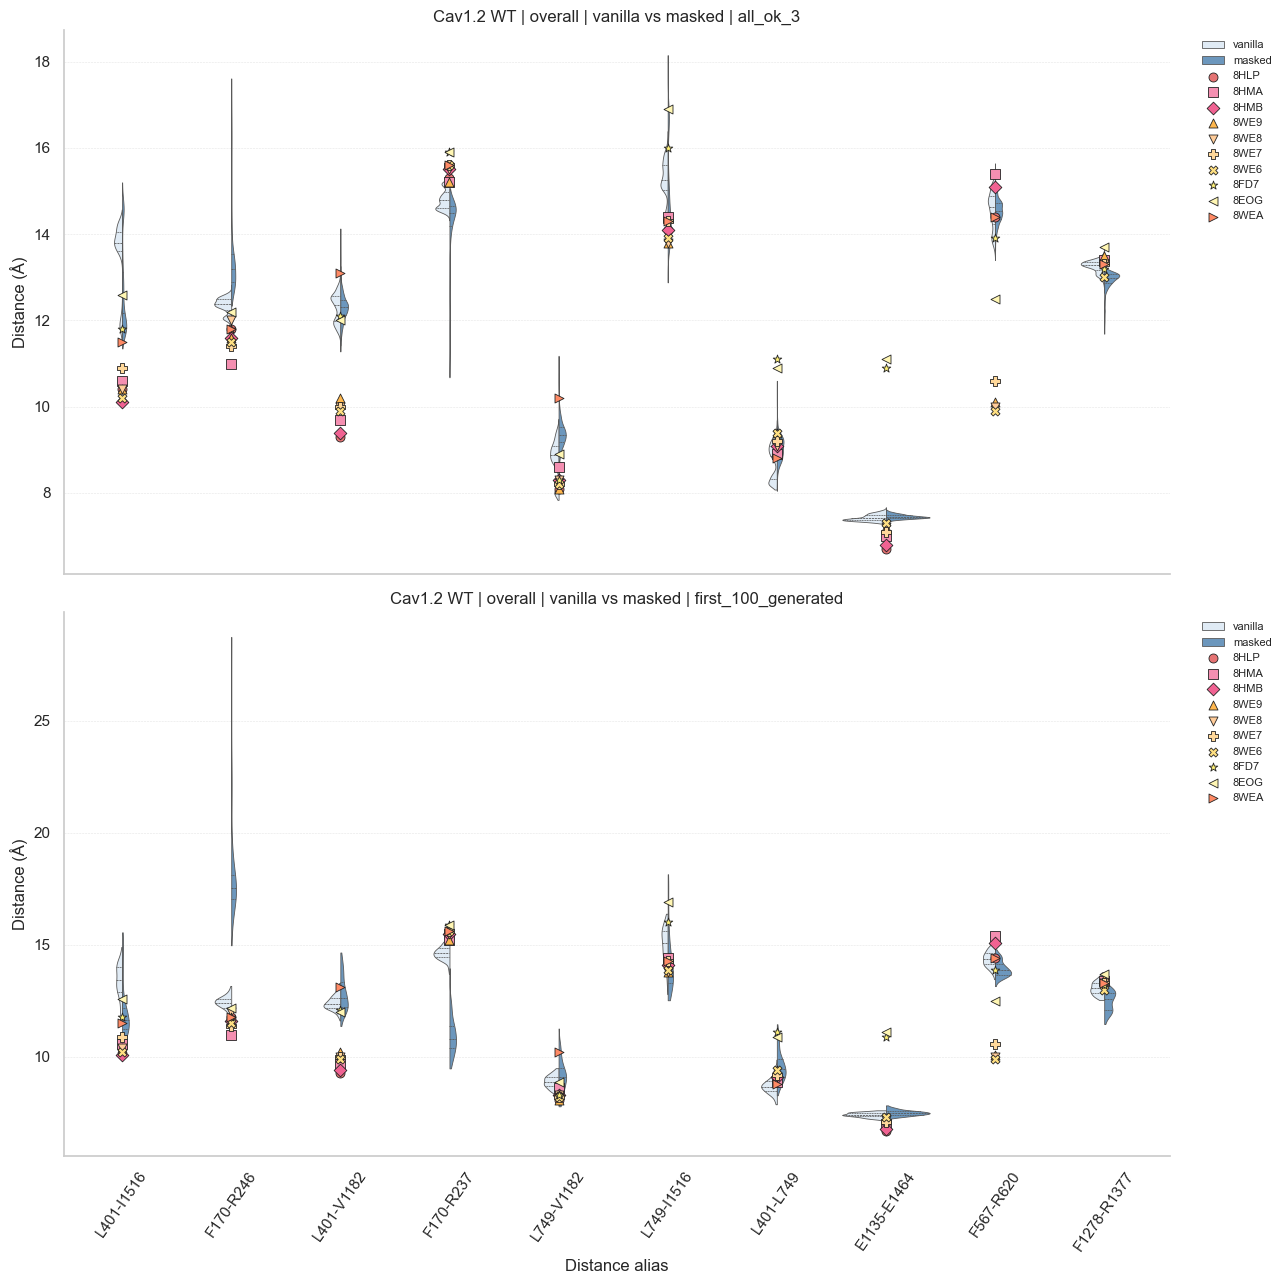

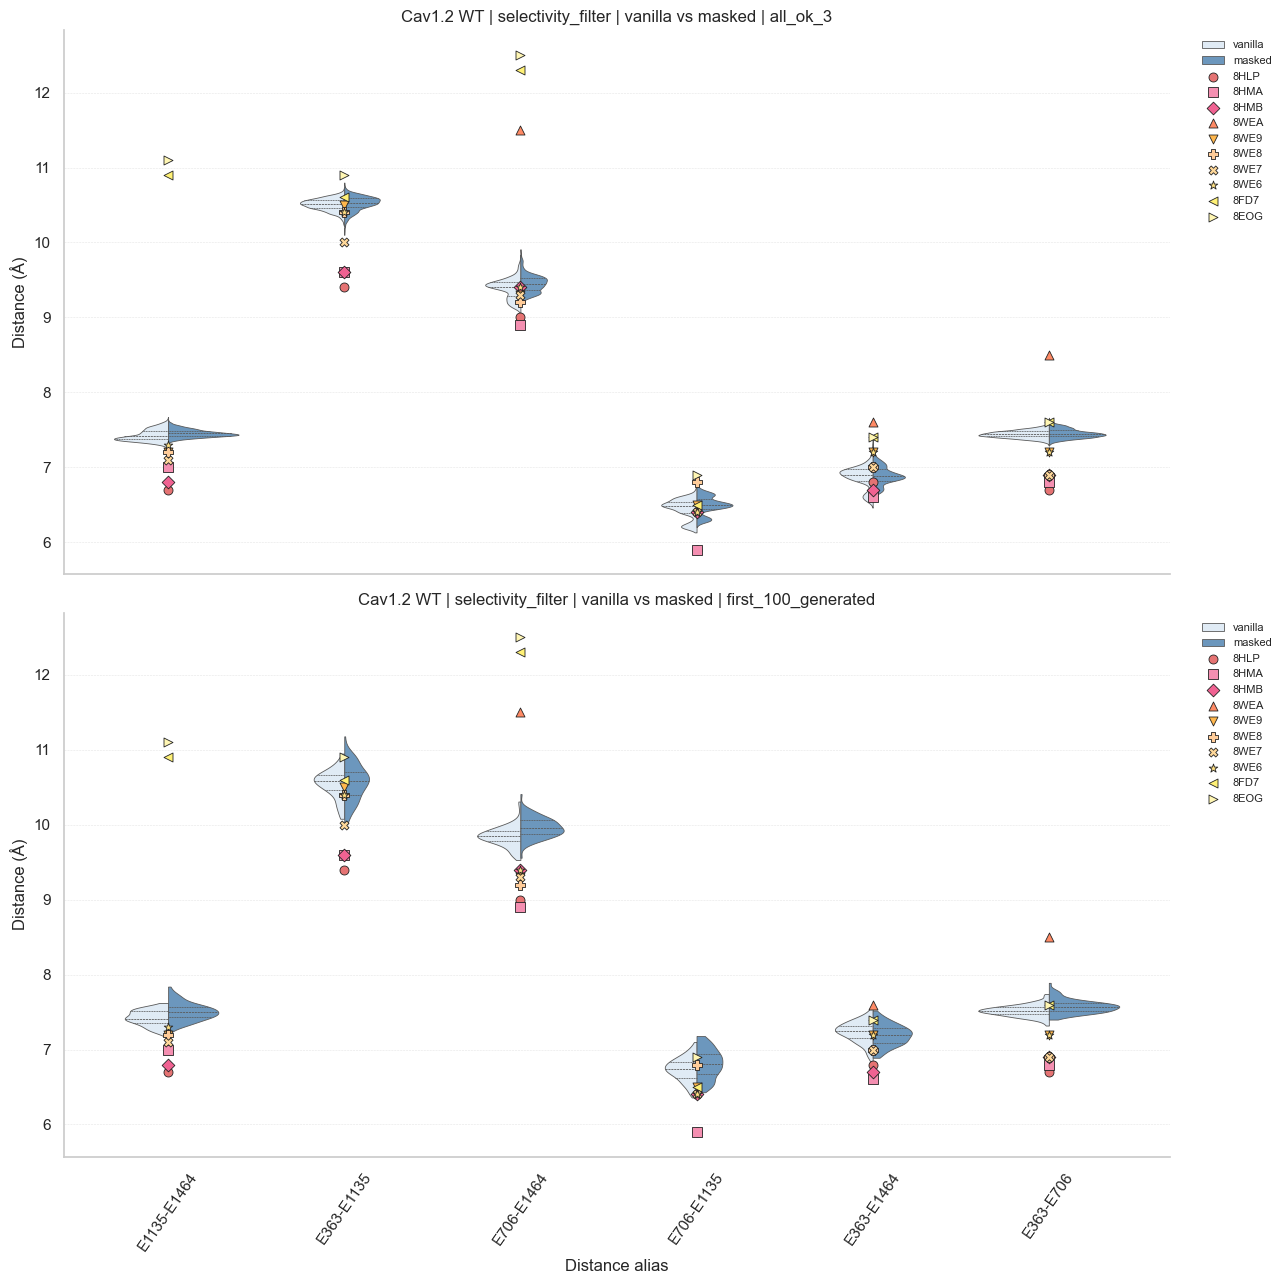

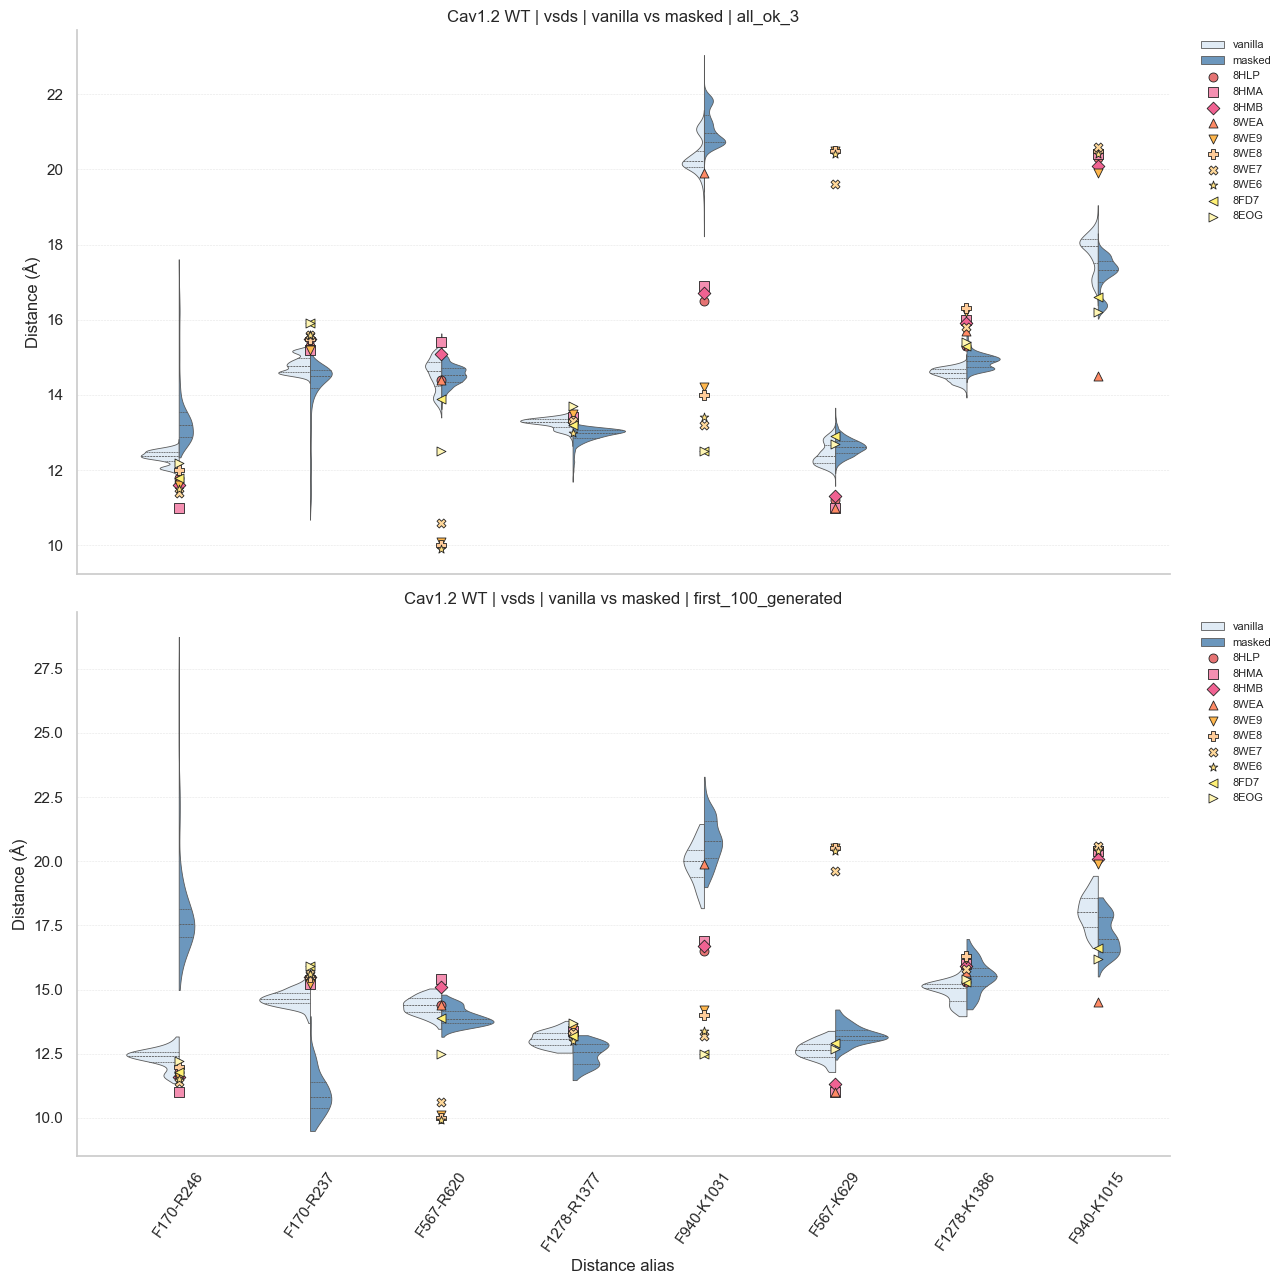

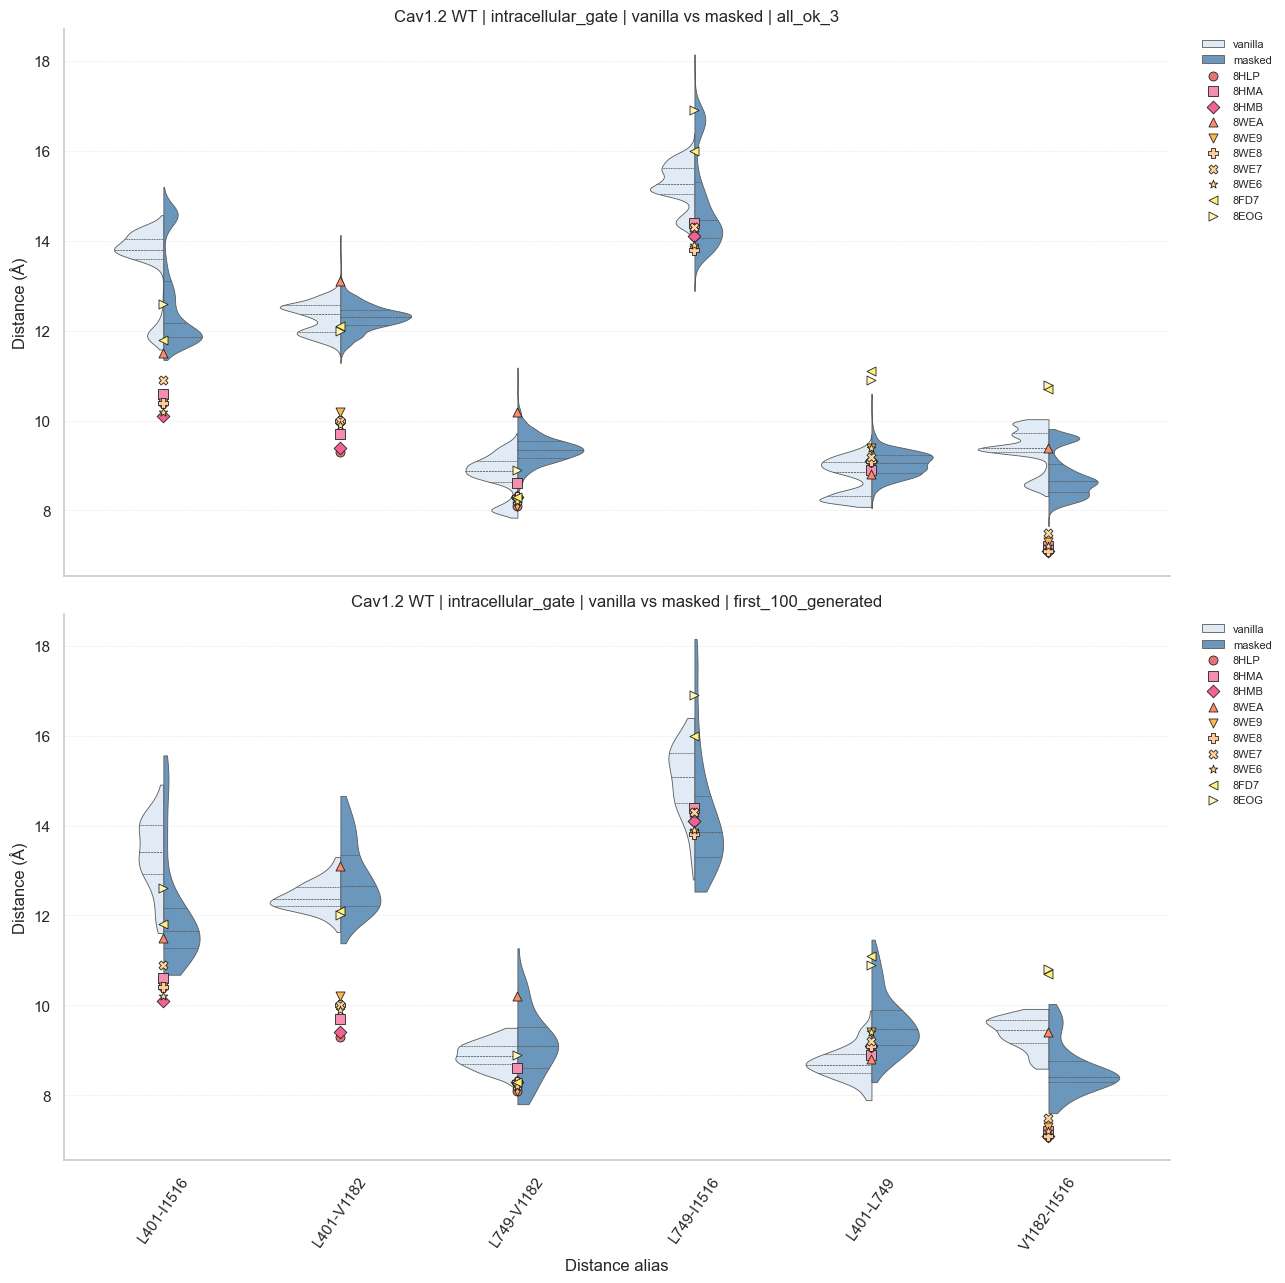

Loading Cav1.2 G402S...


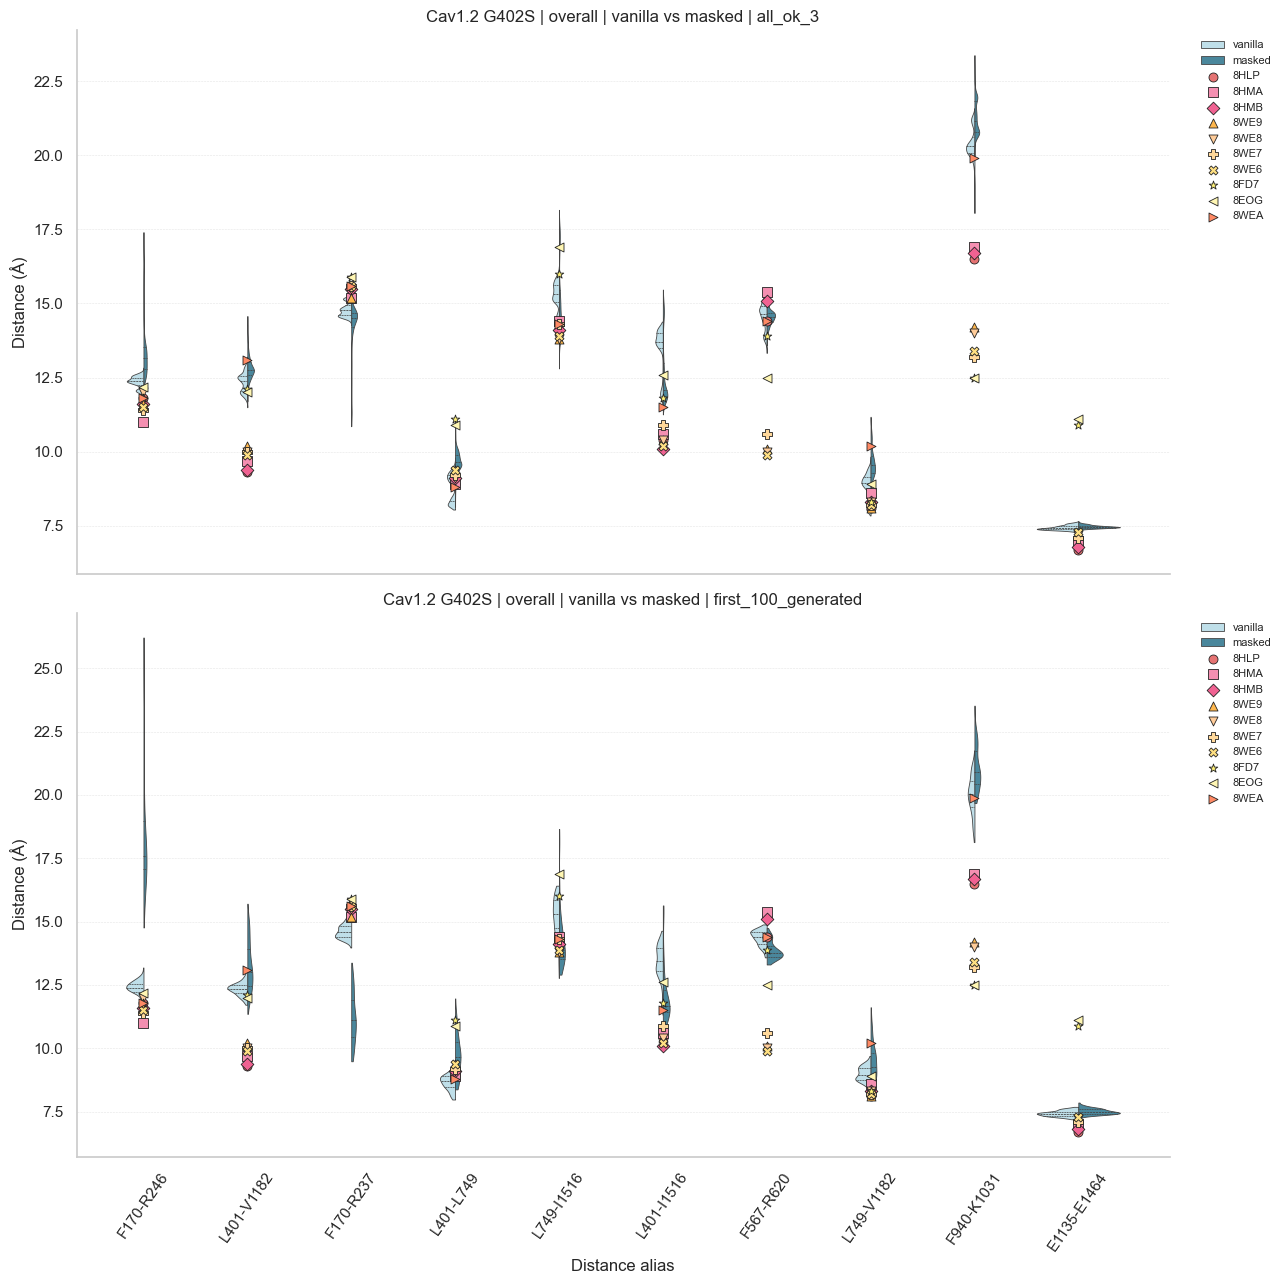

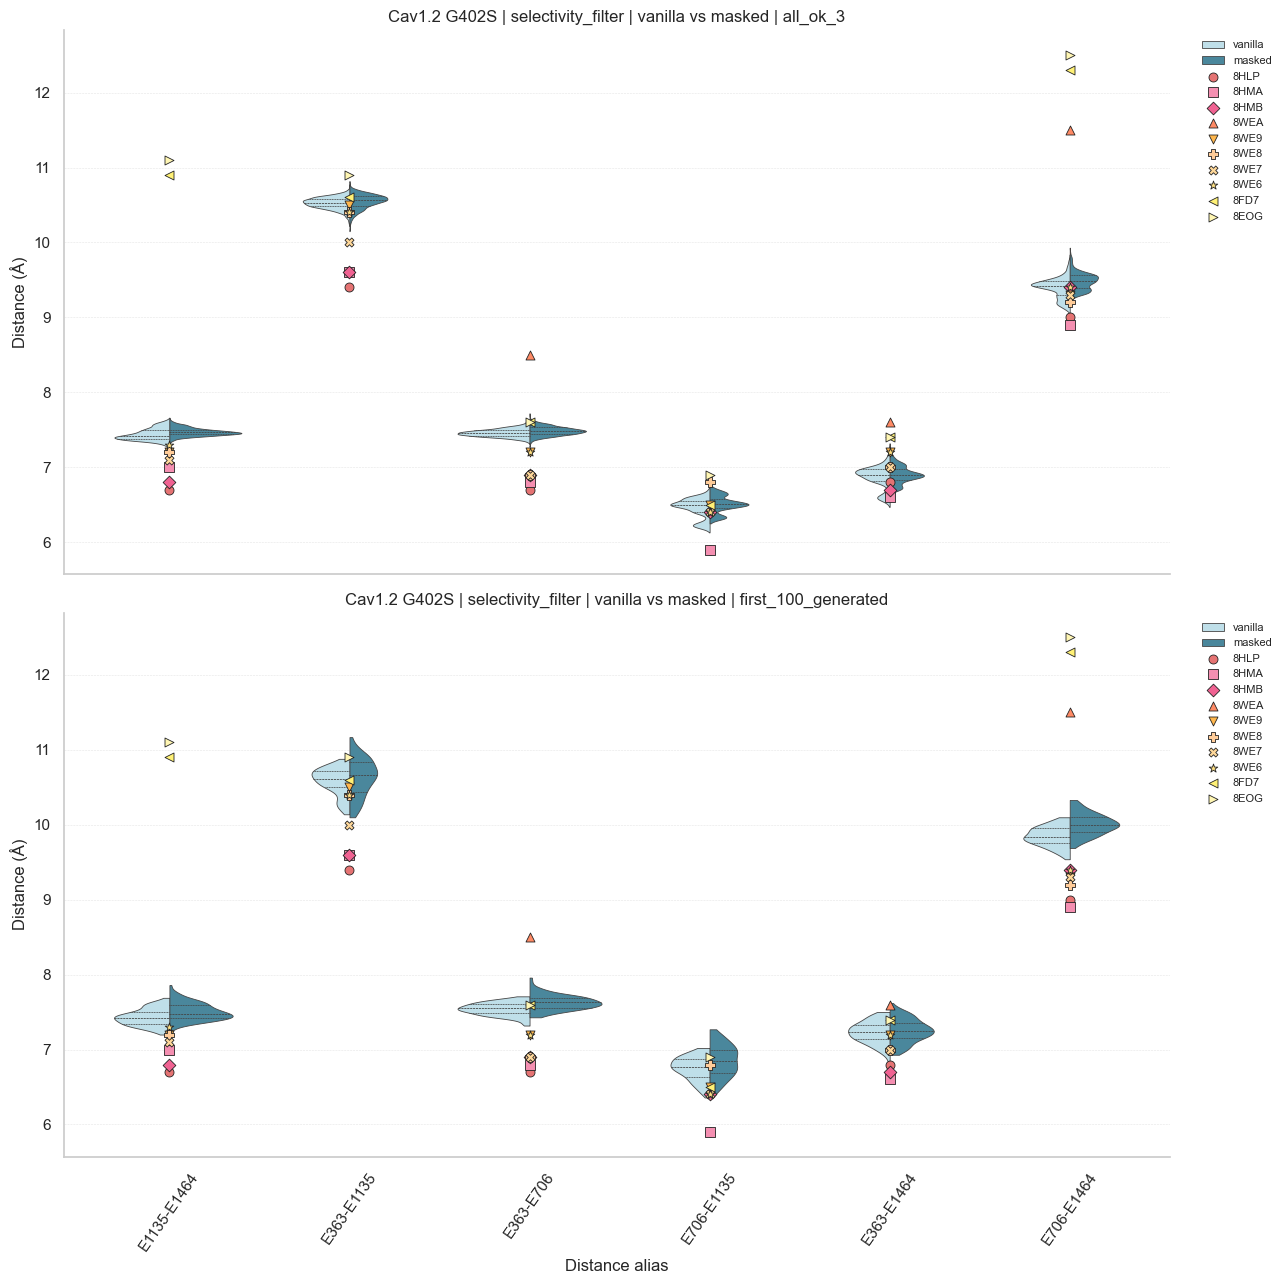

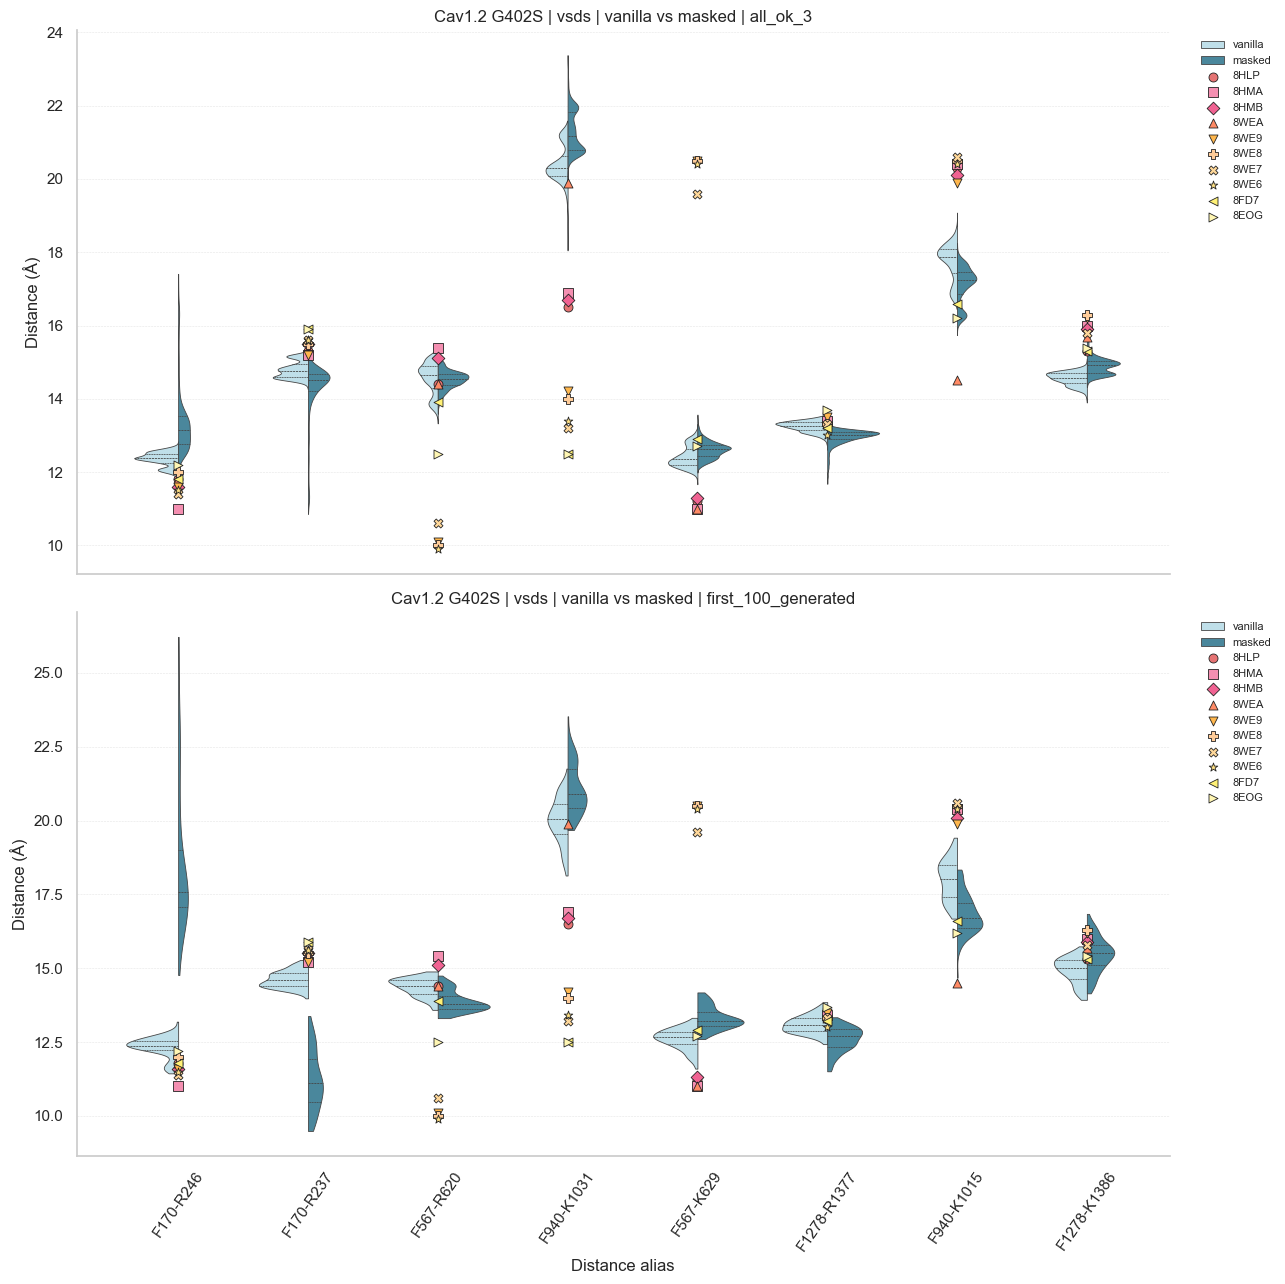

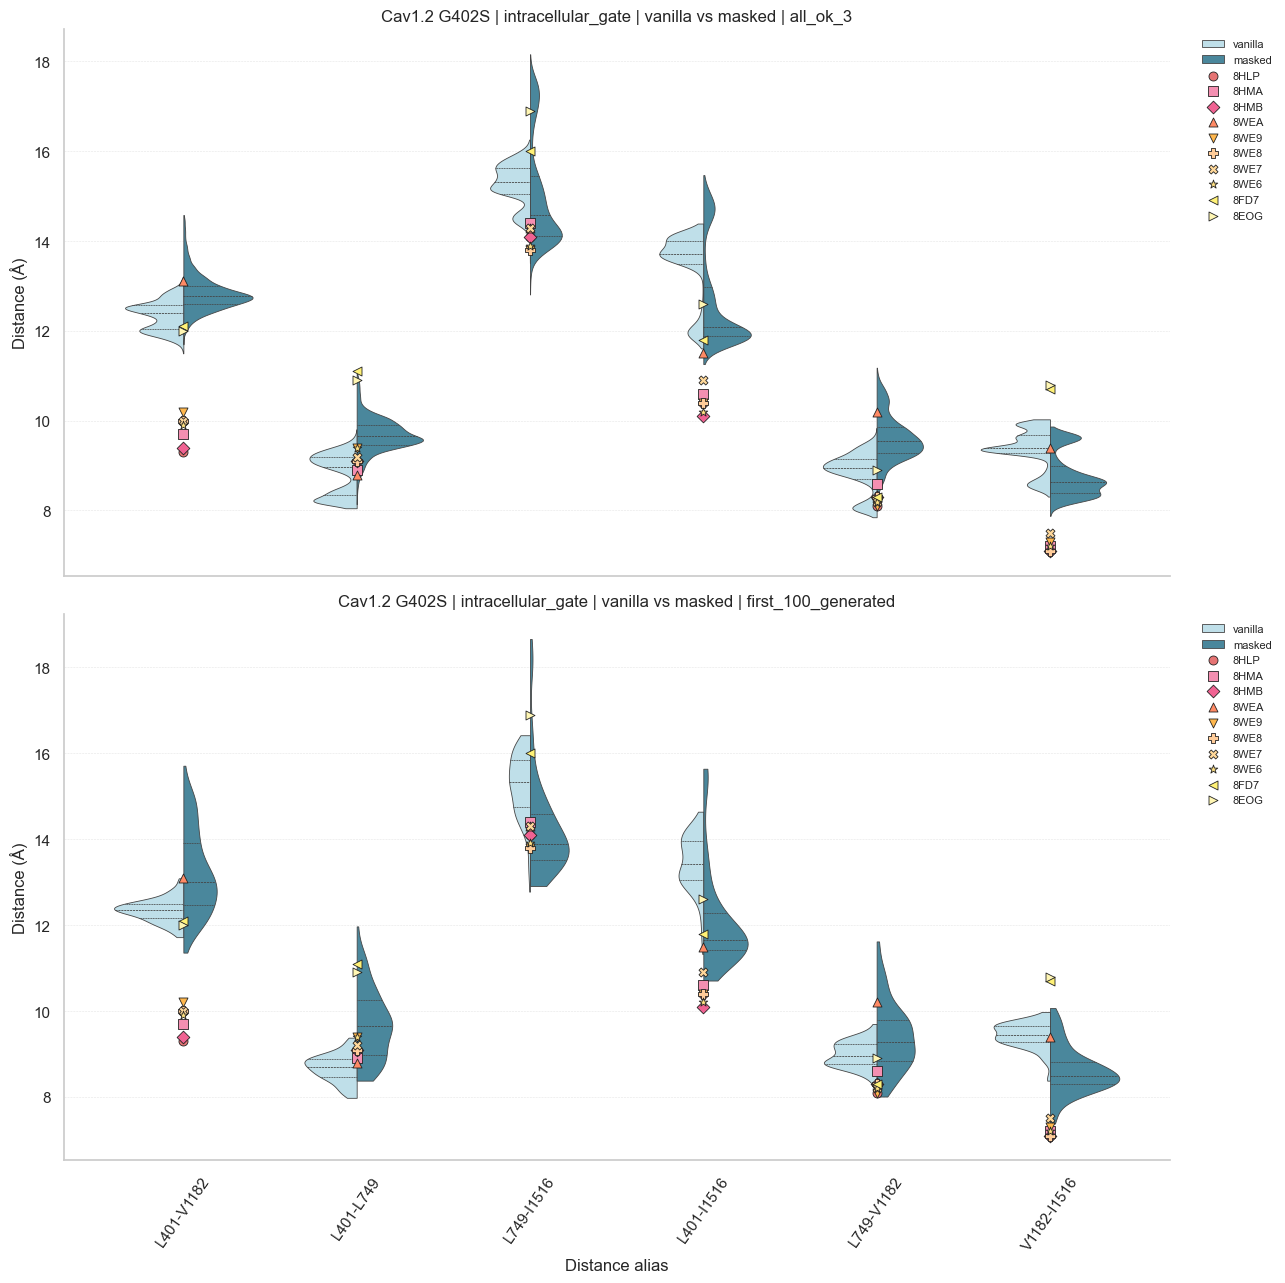

Loading Cav1.2 G406R...


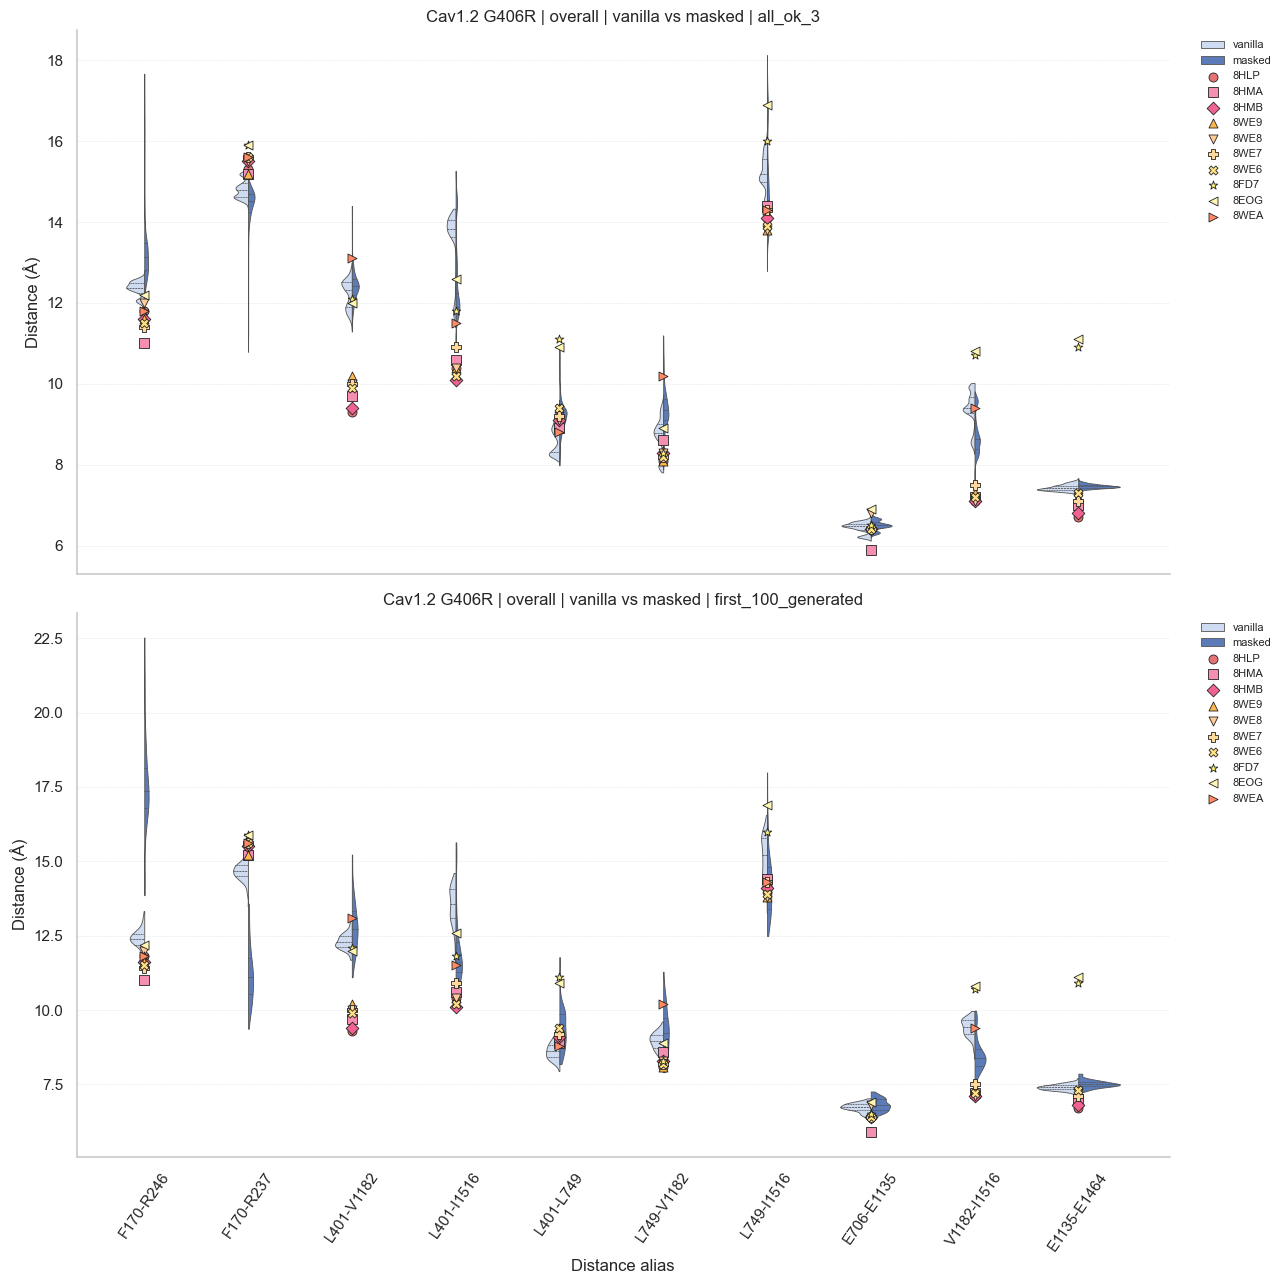

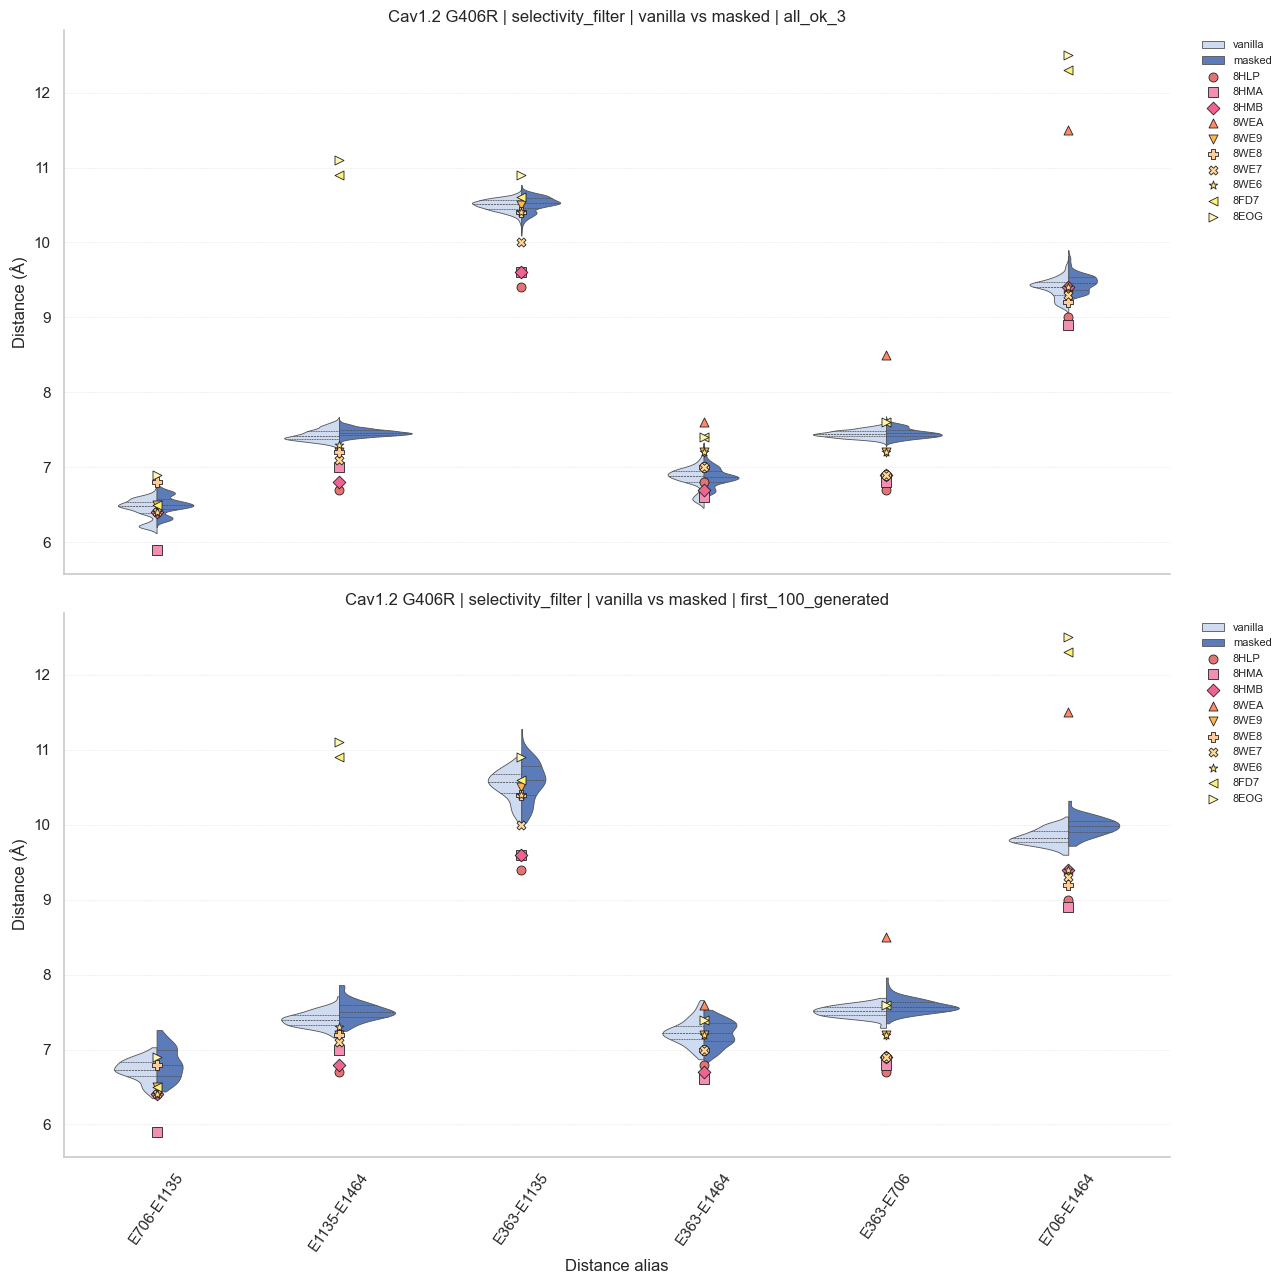

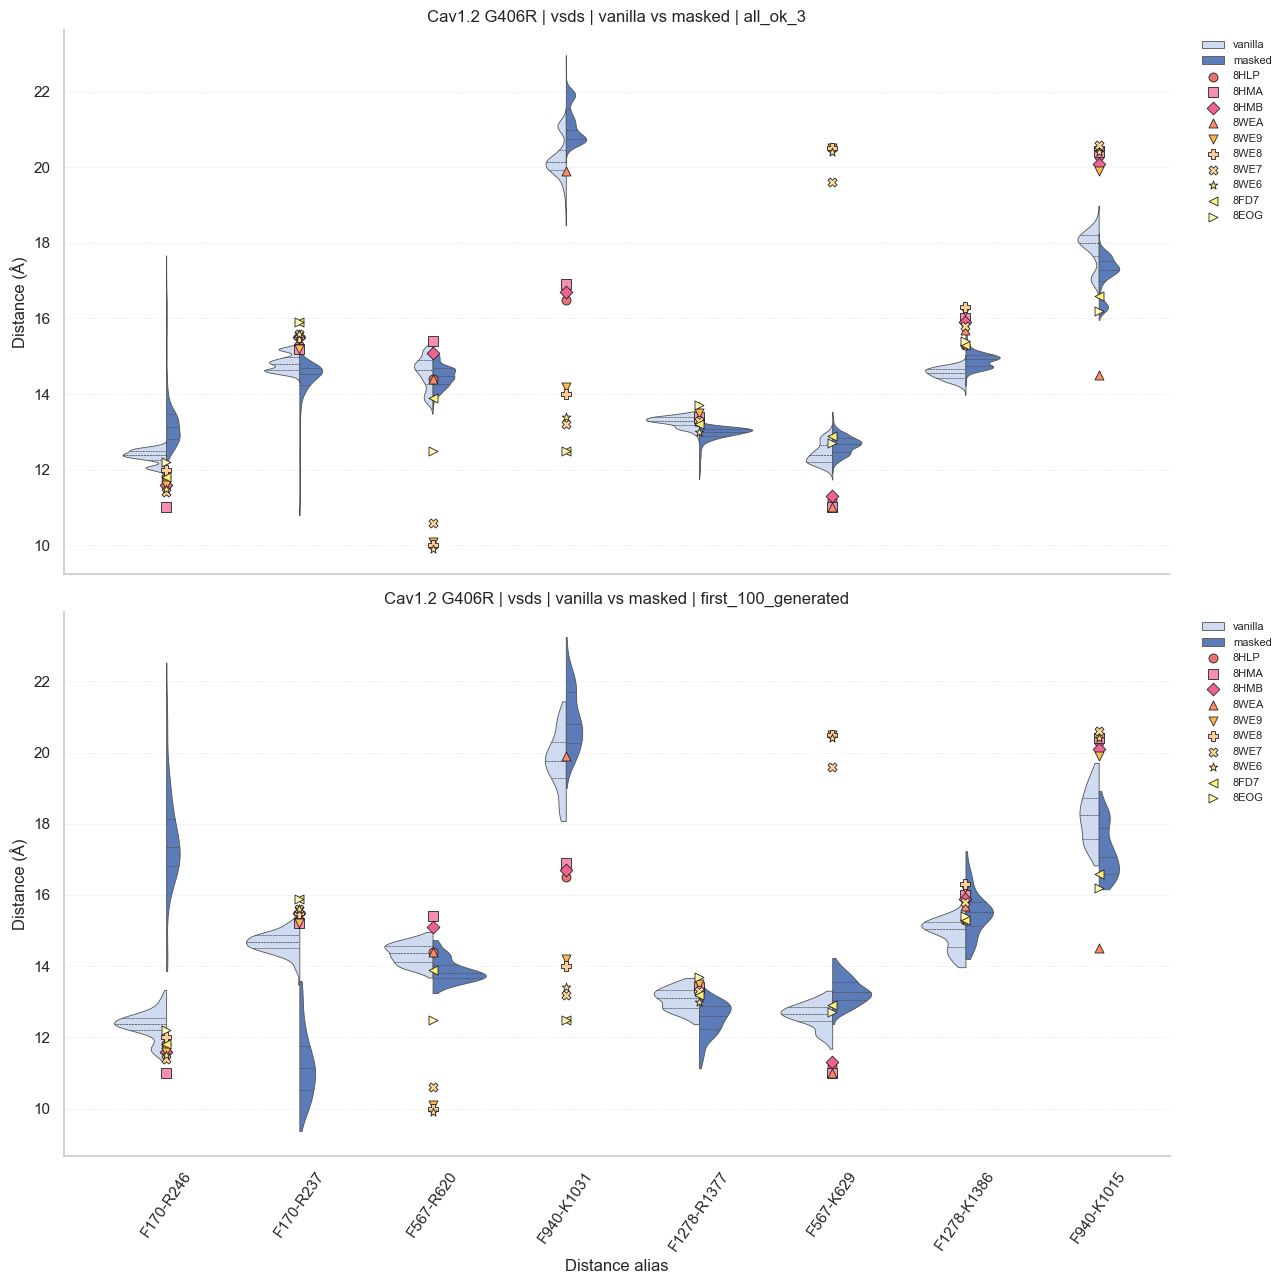

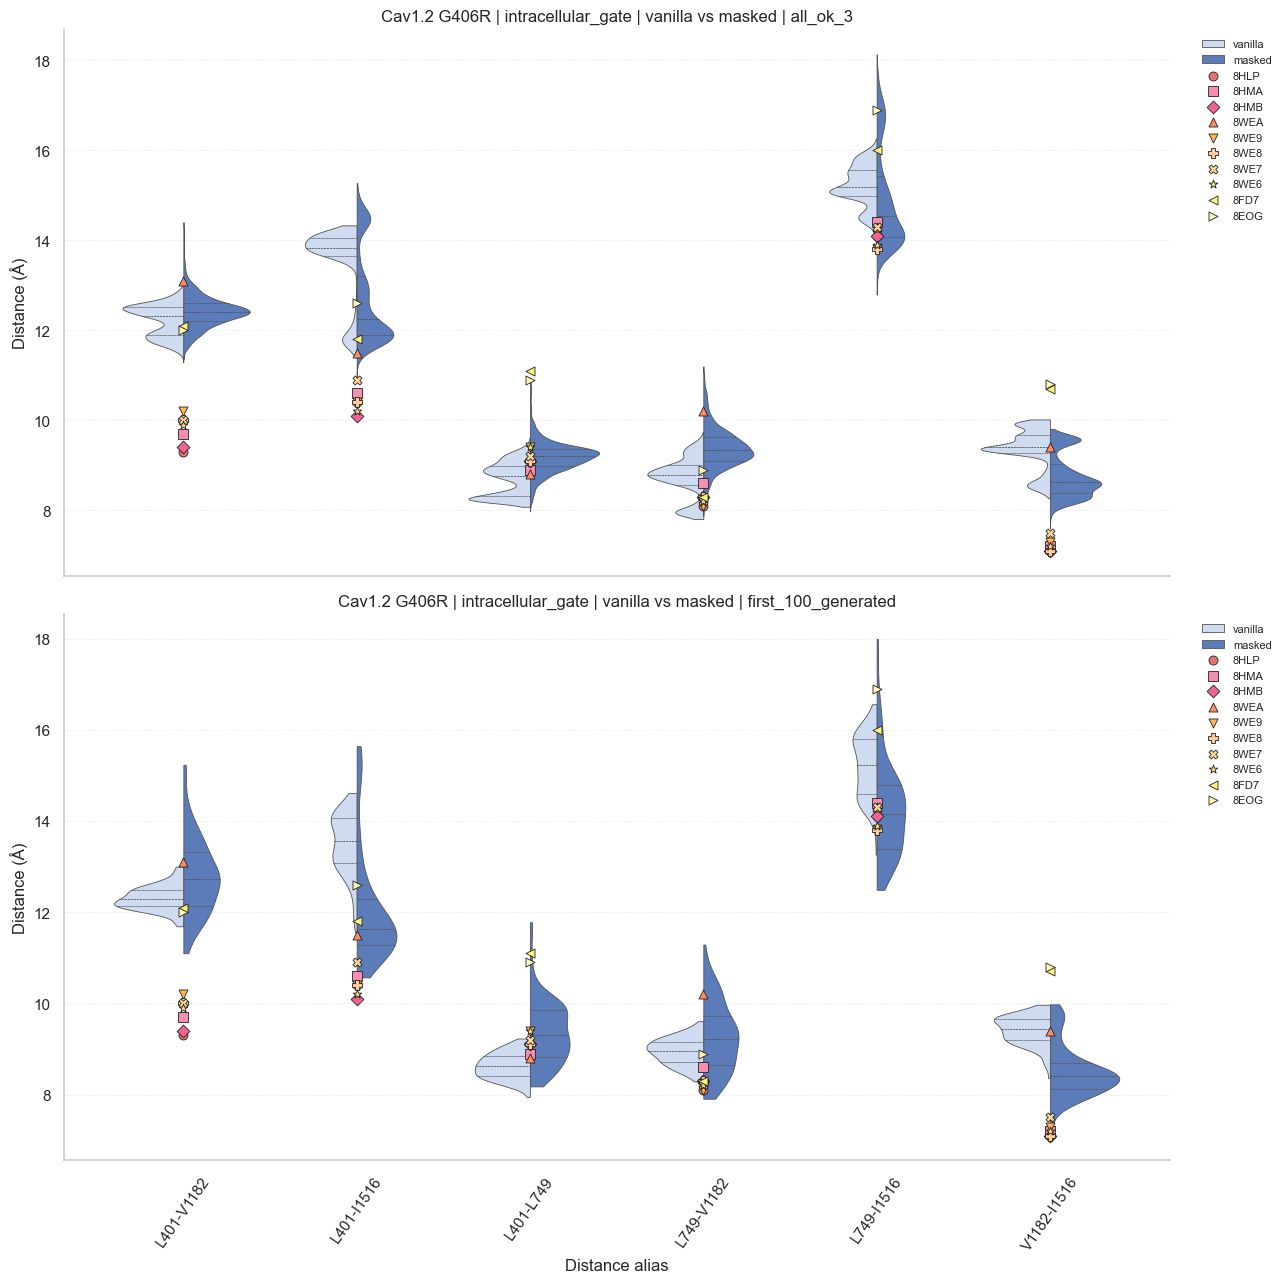

Loading Kv2.1 WT...


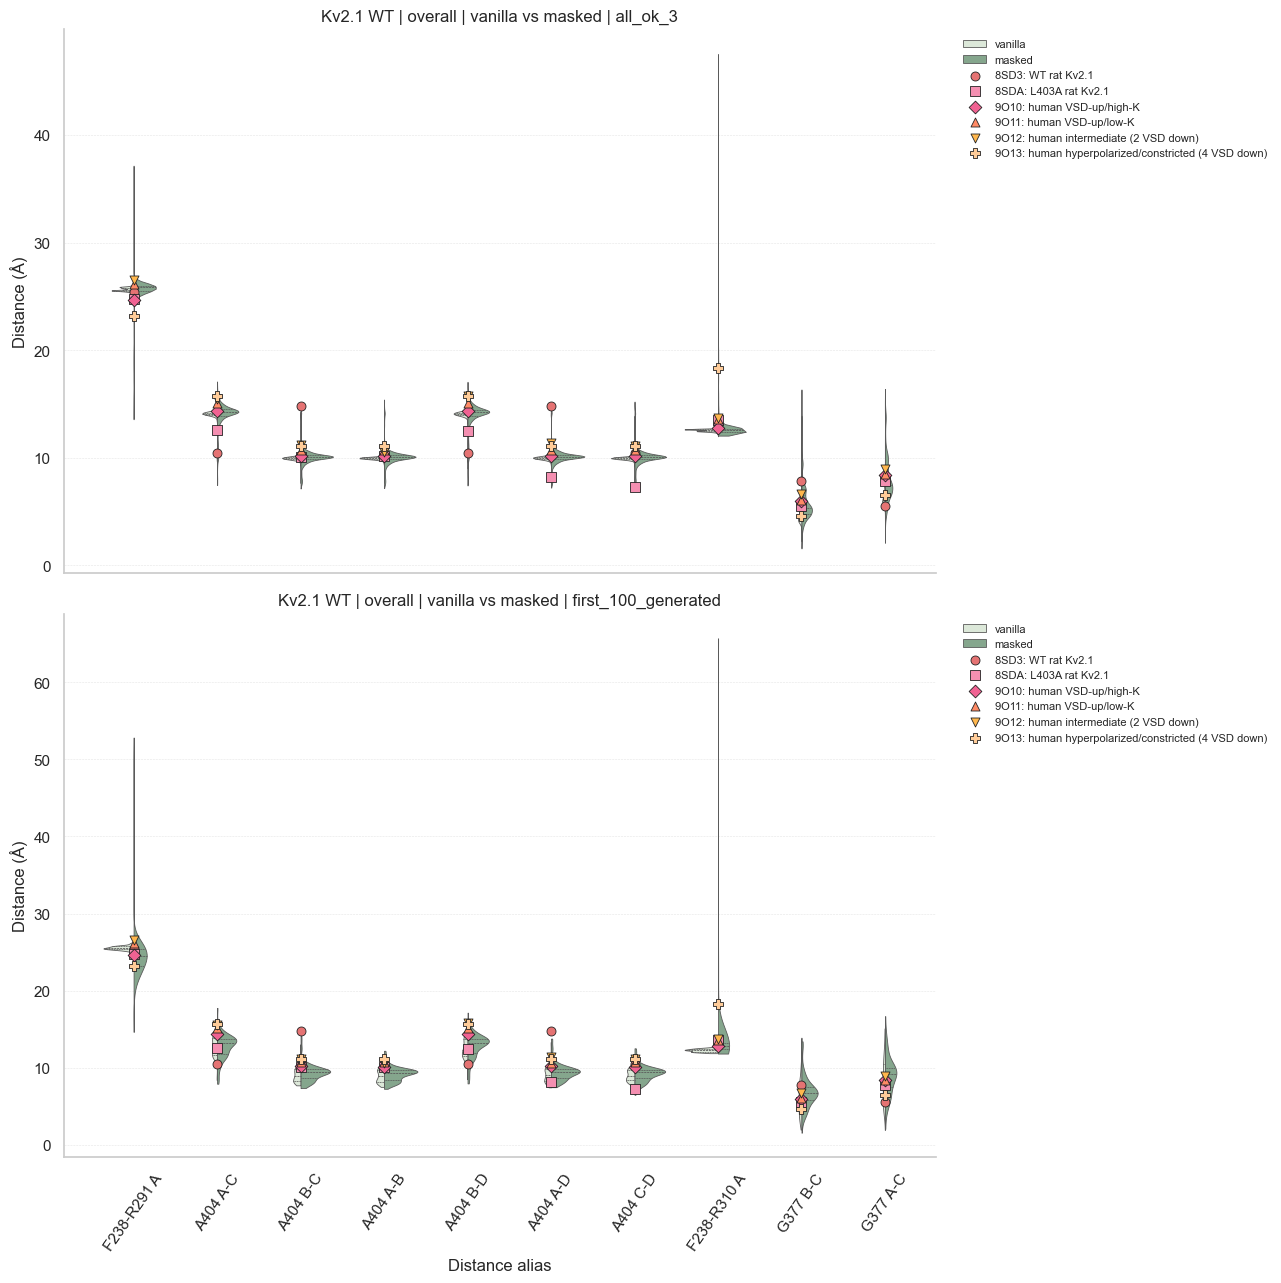

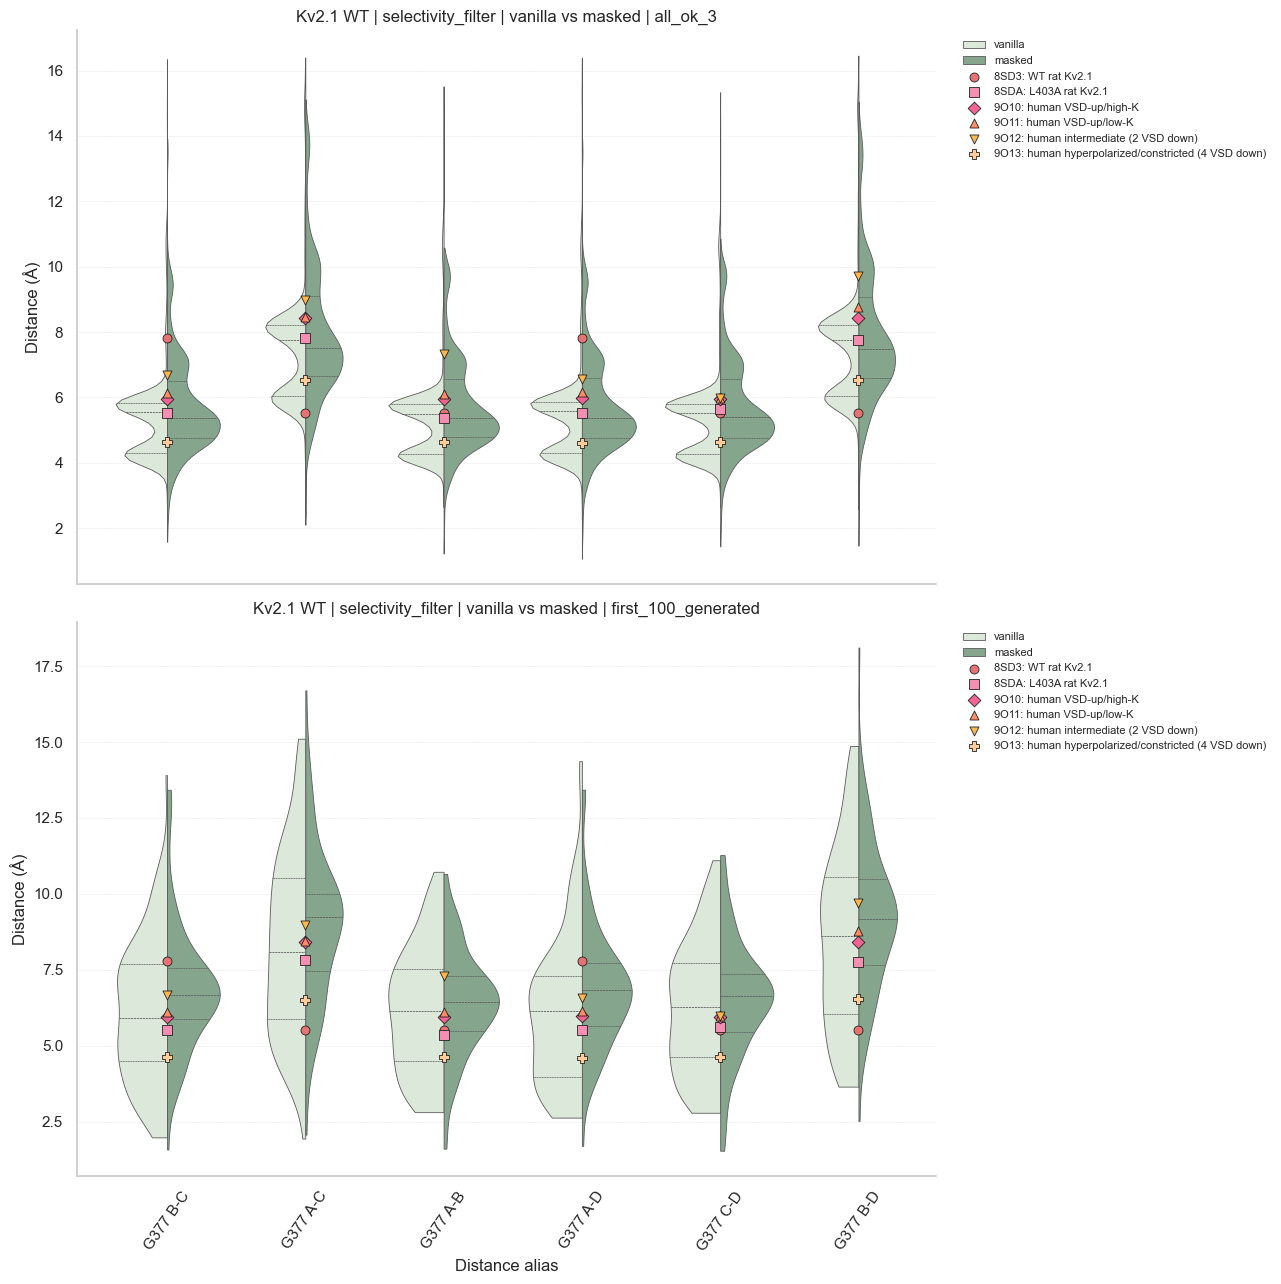

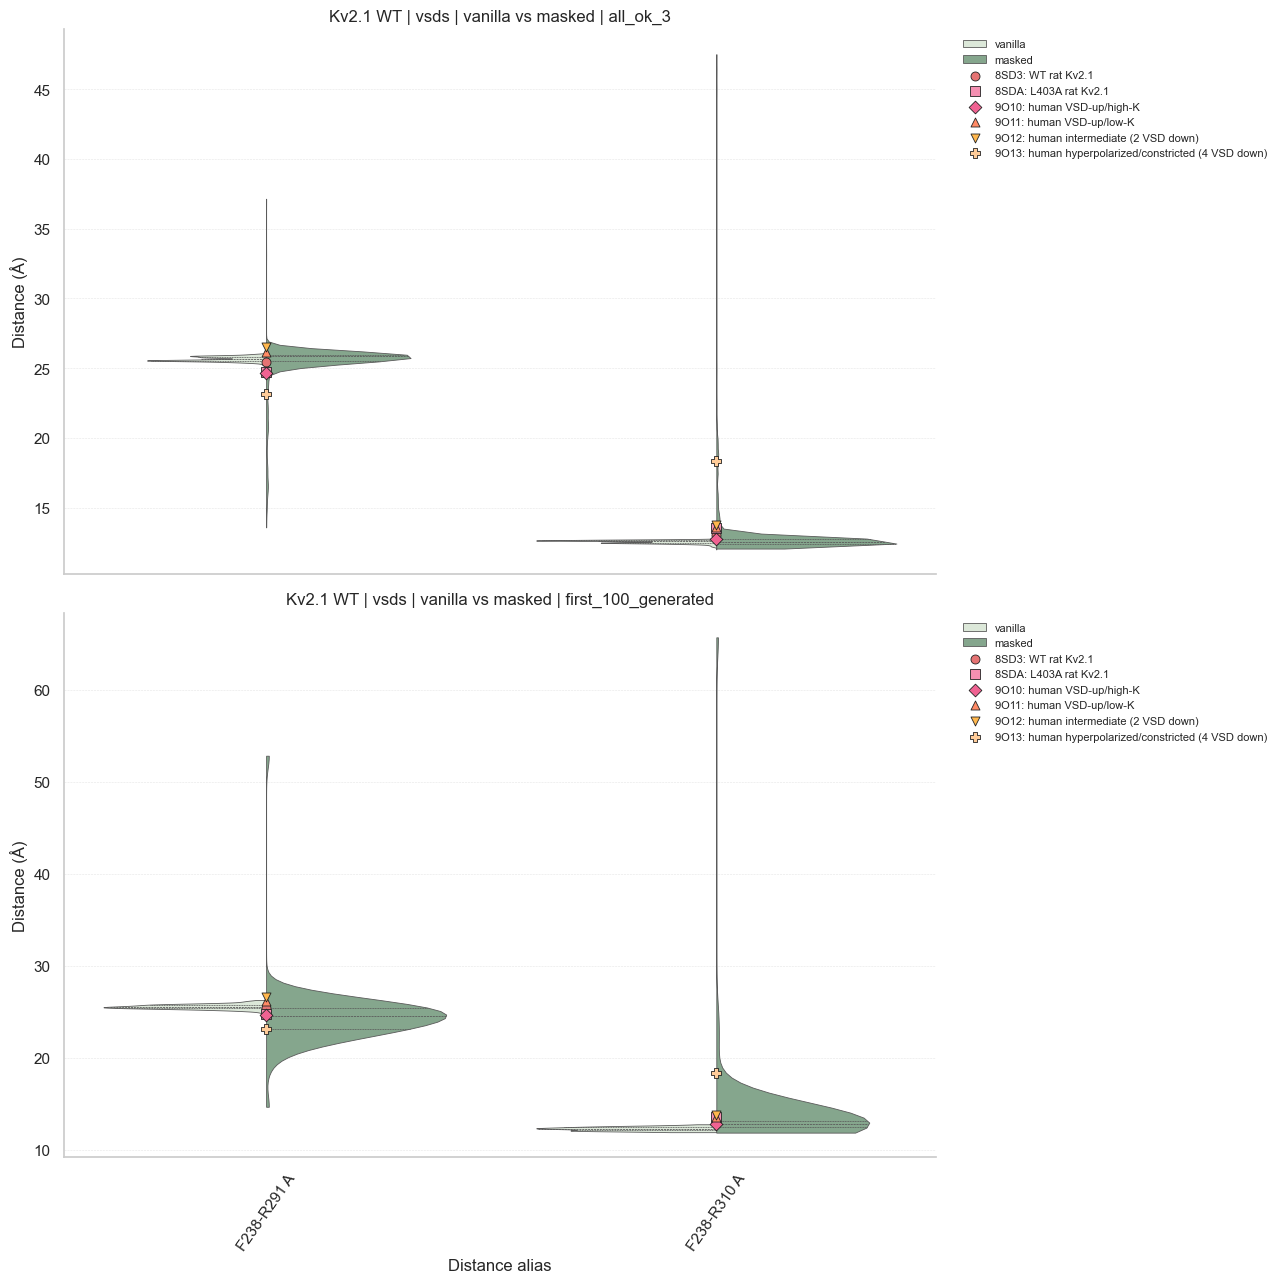

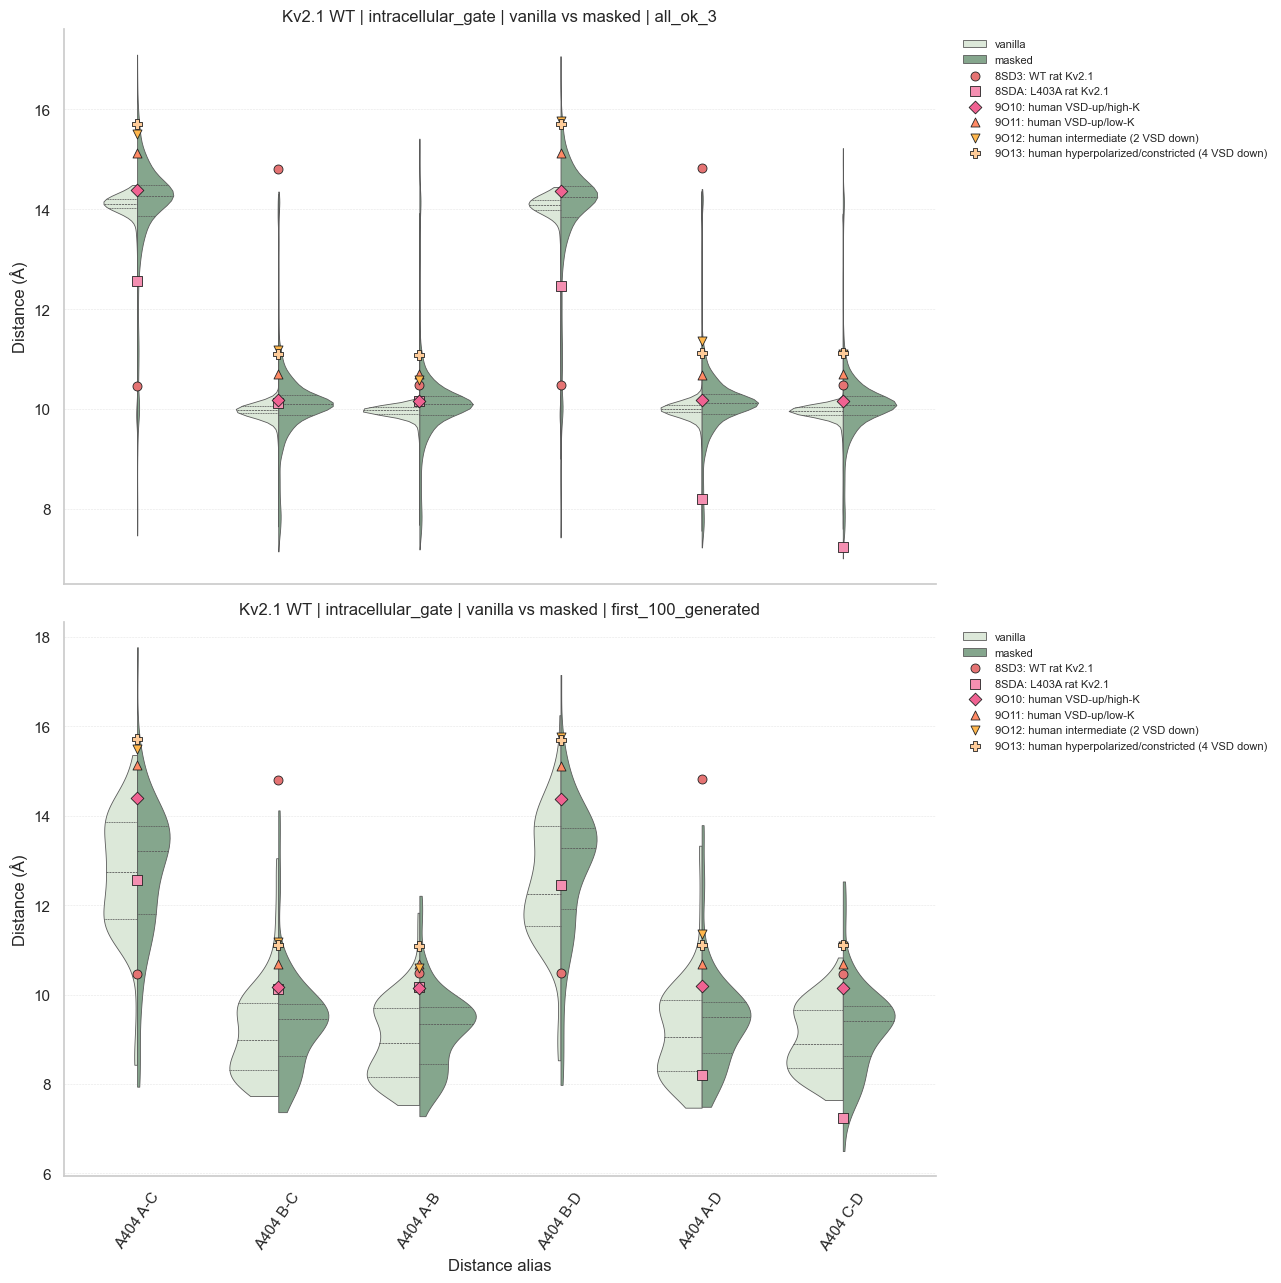

Loading Kv2.1 F412L...


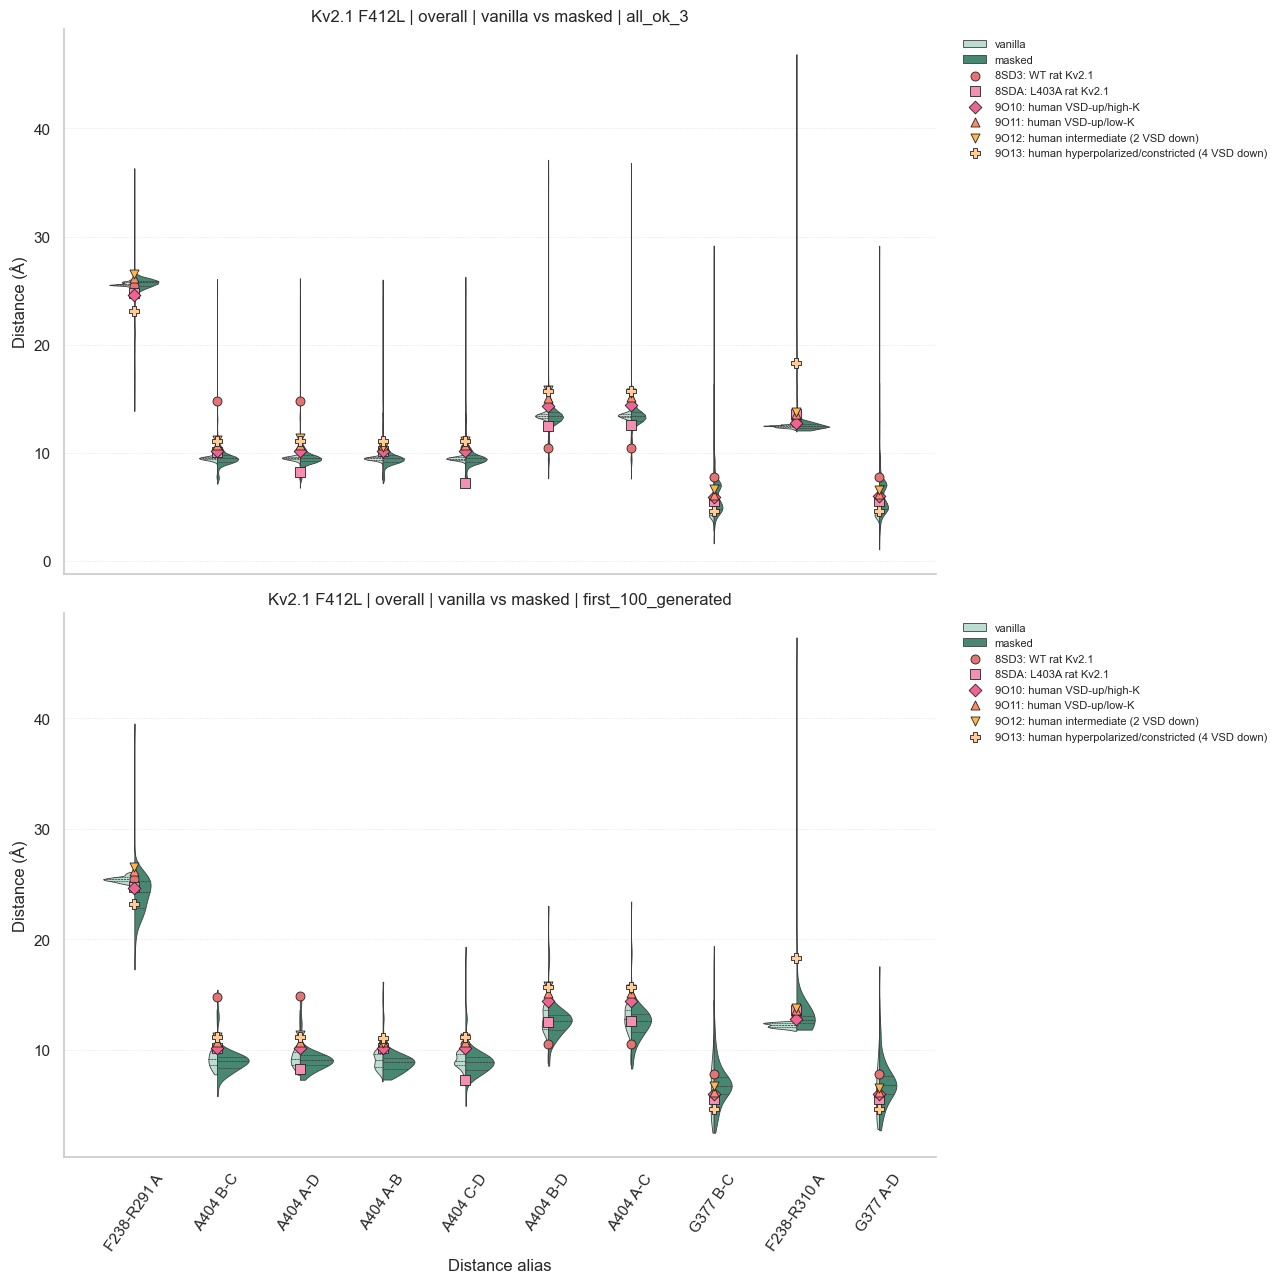

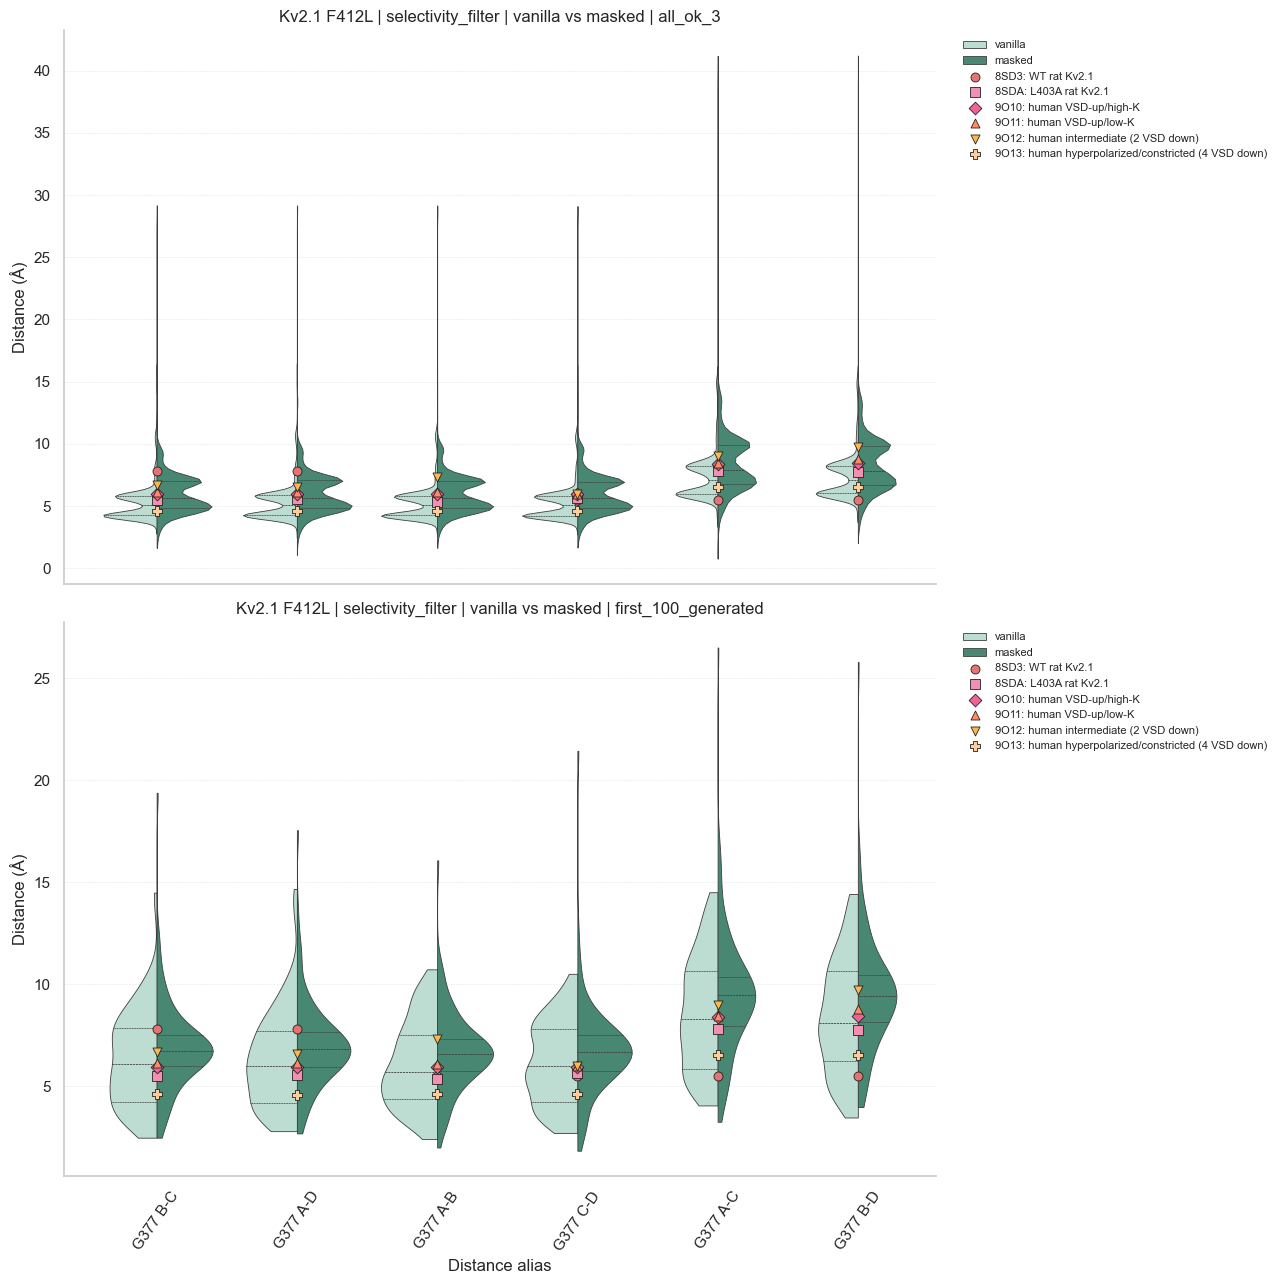

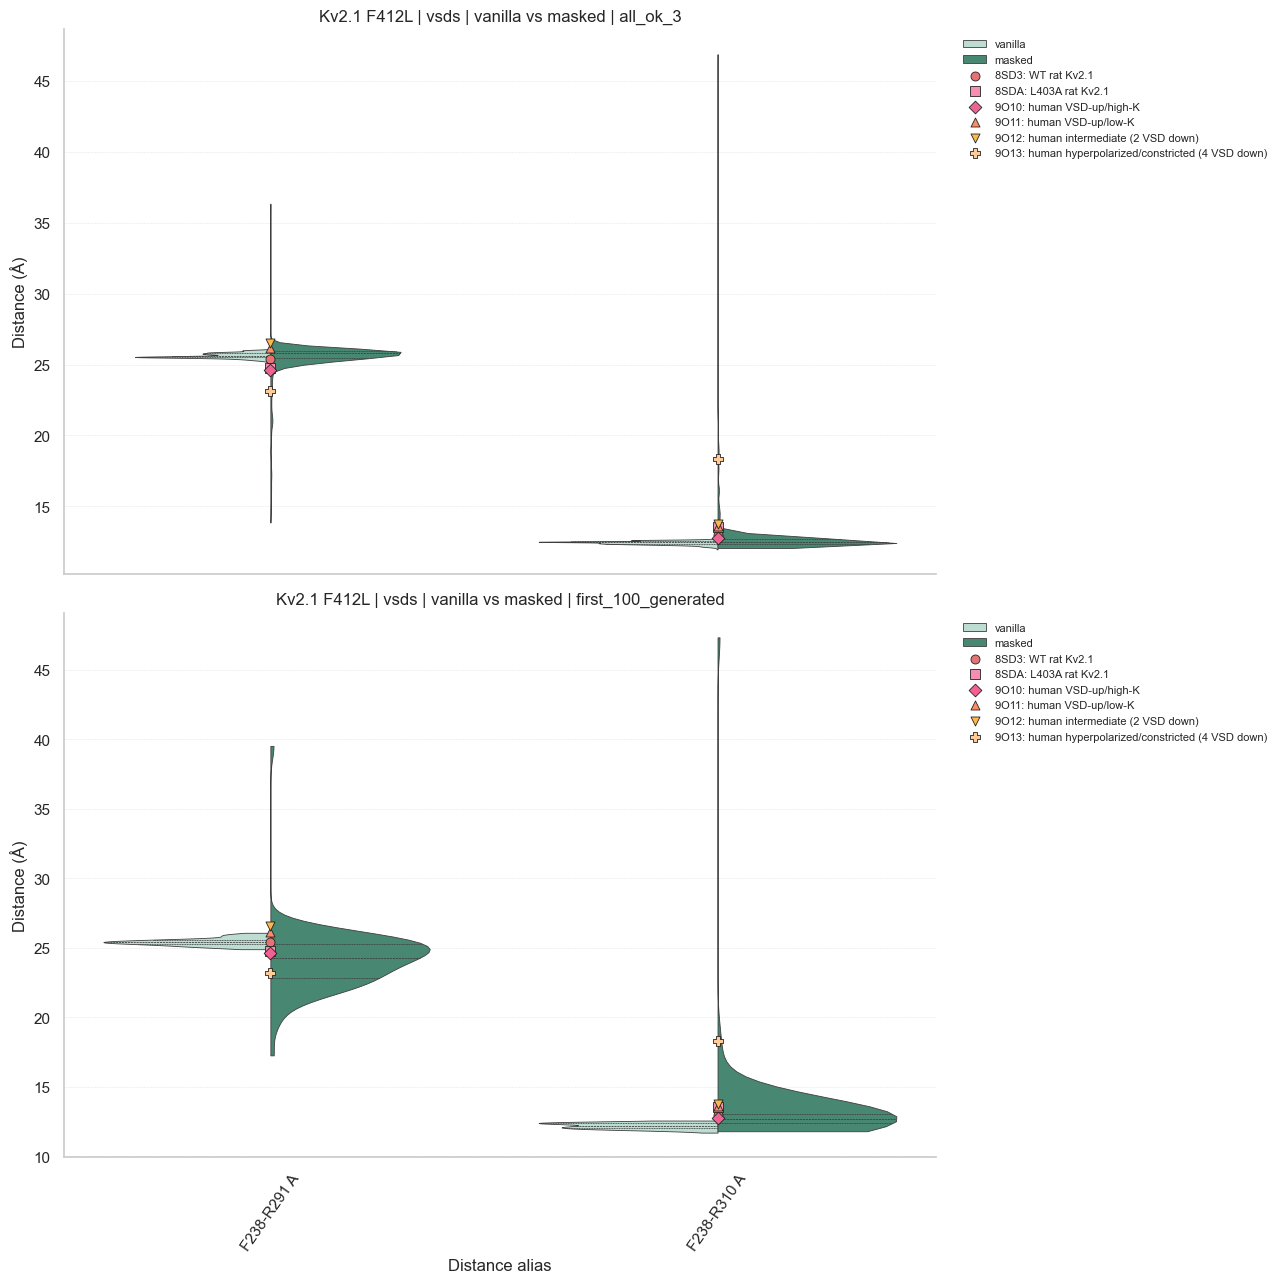

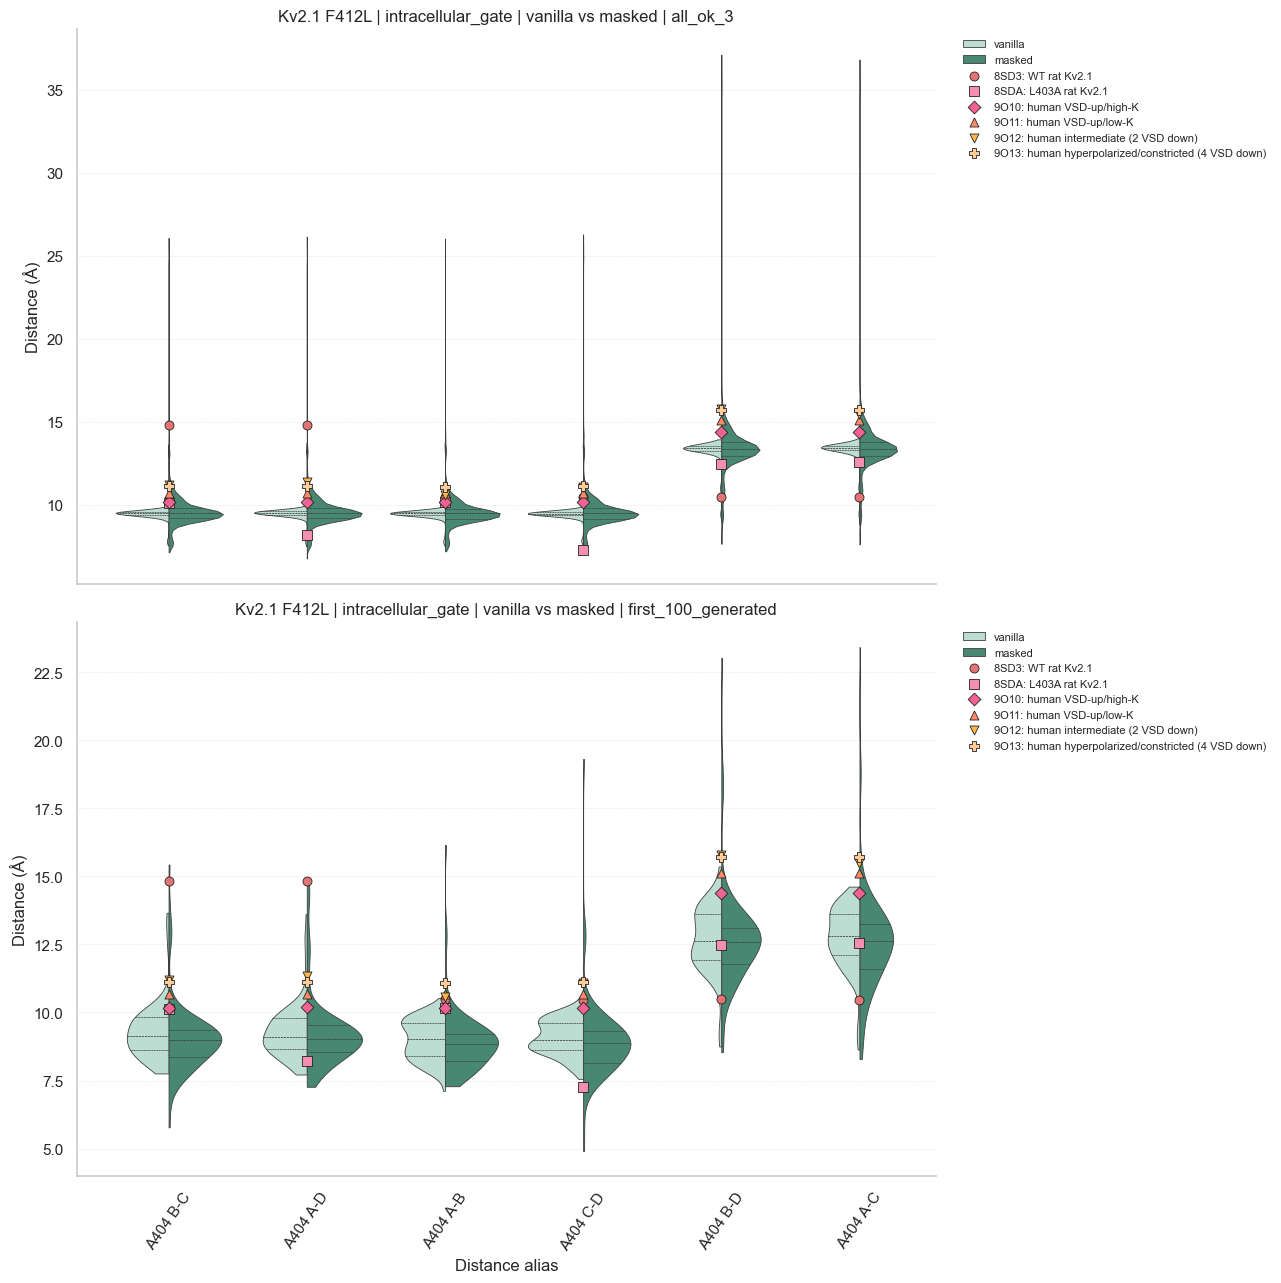

Loading Kv2.1 L403A...


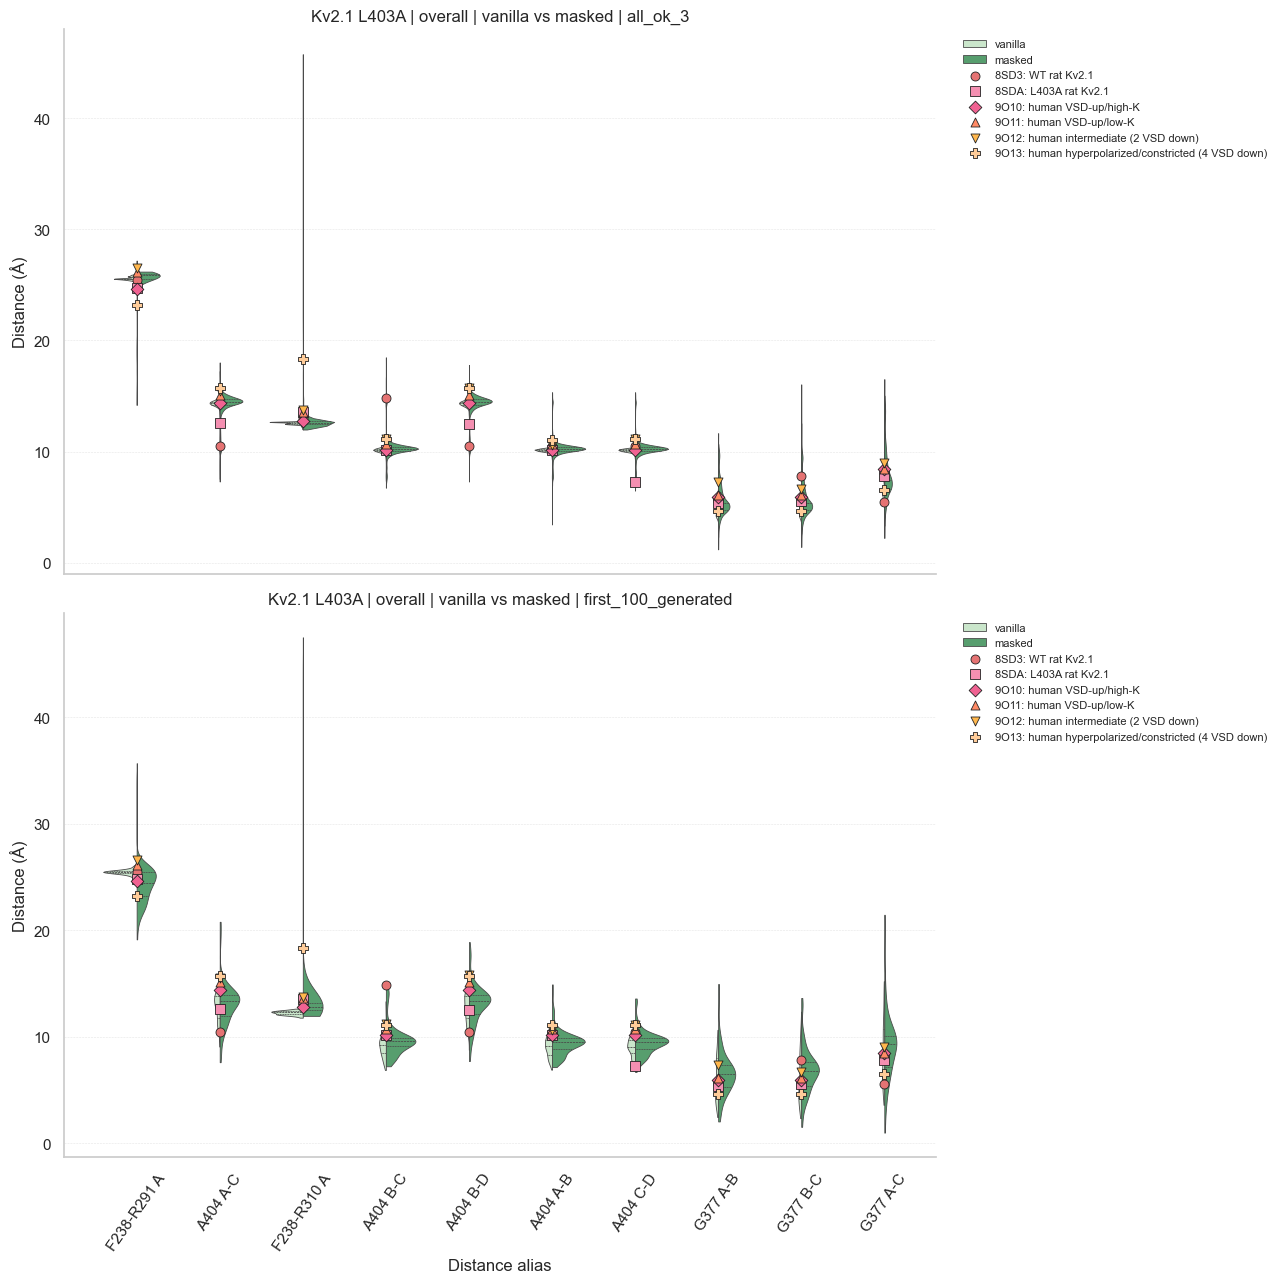

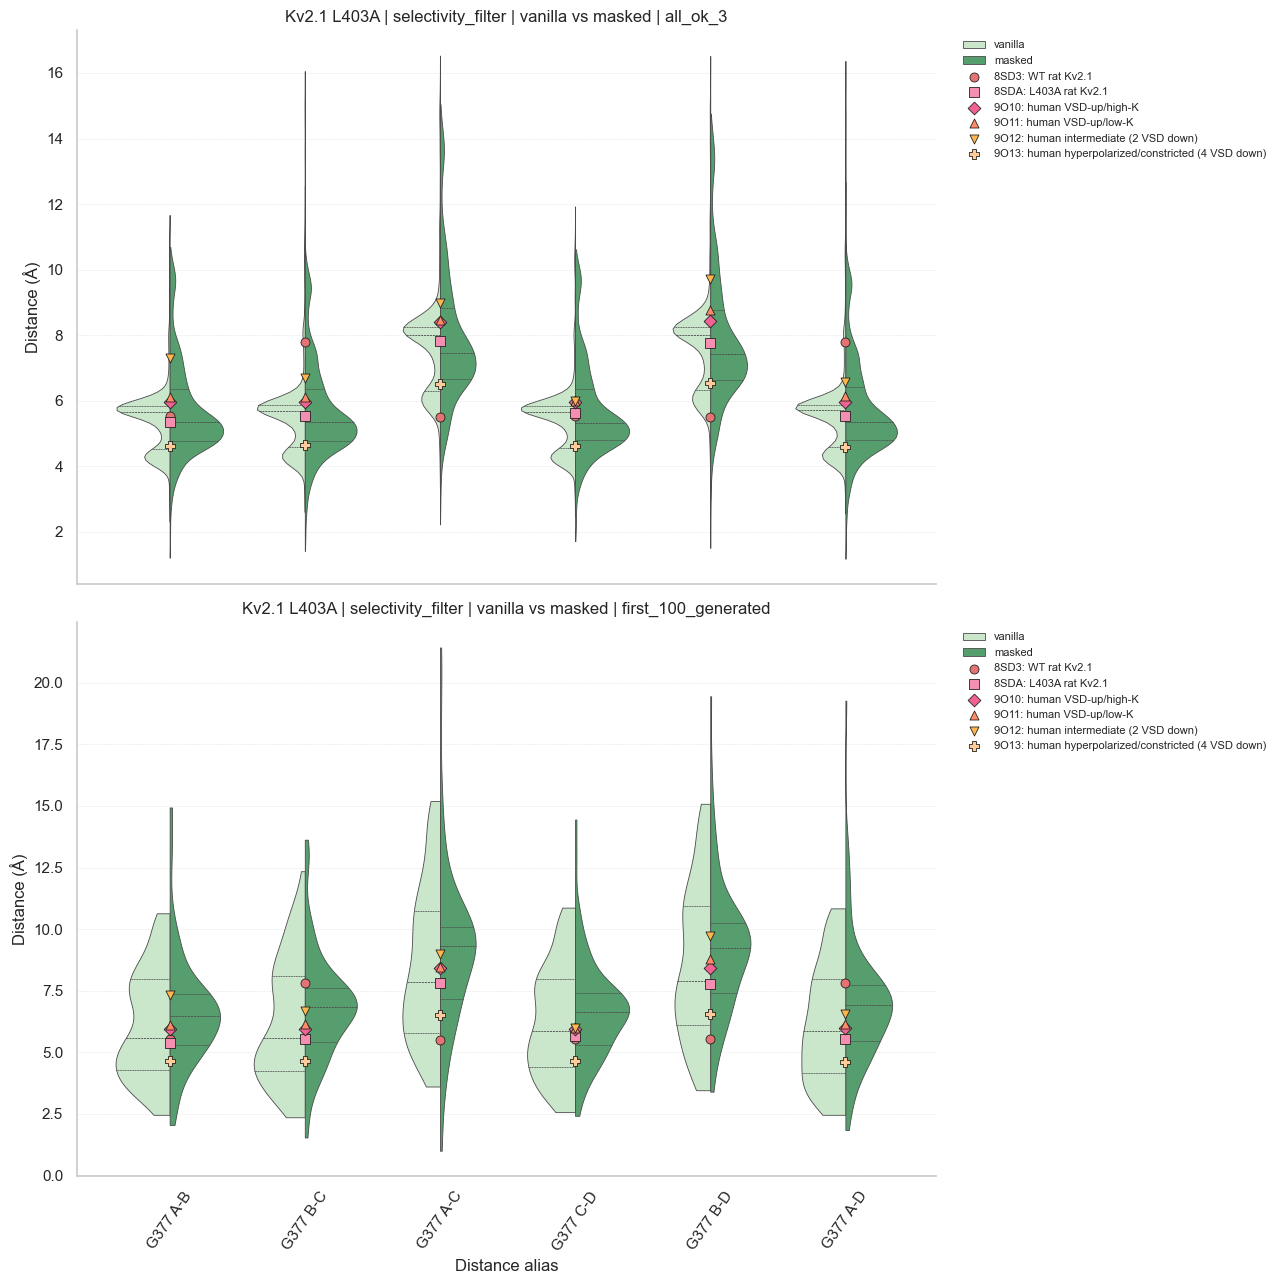

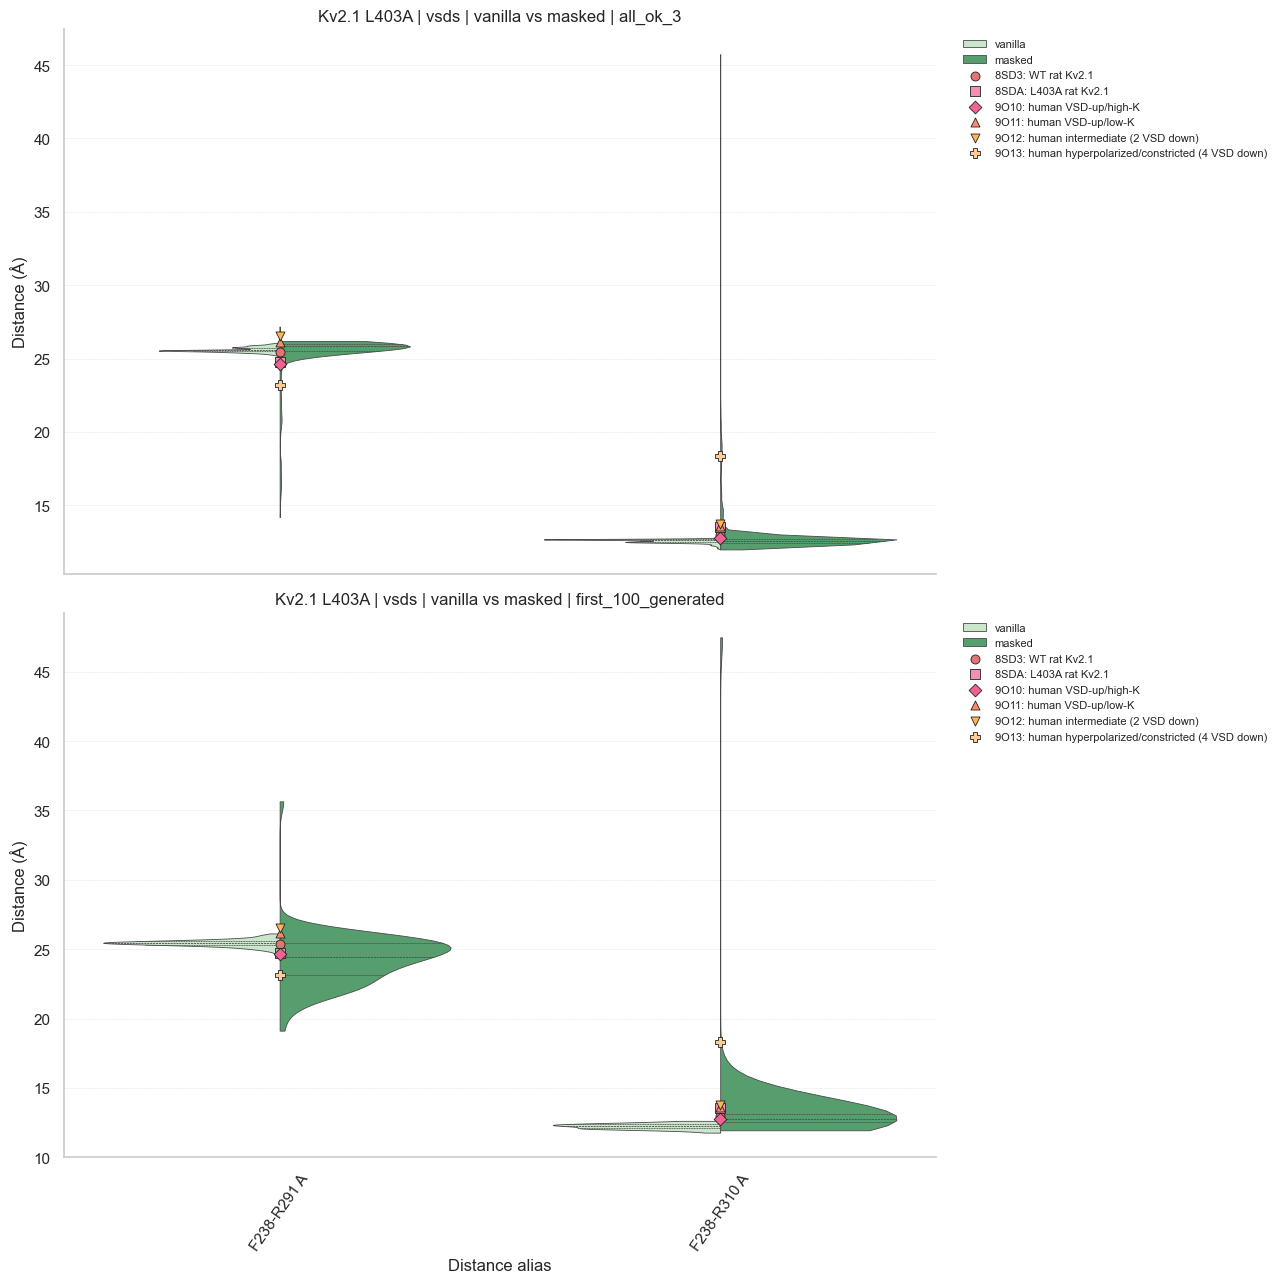

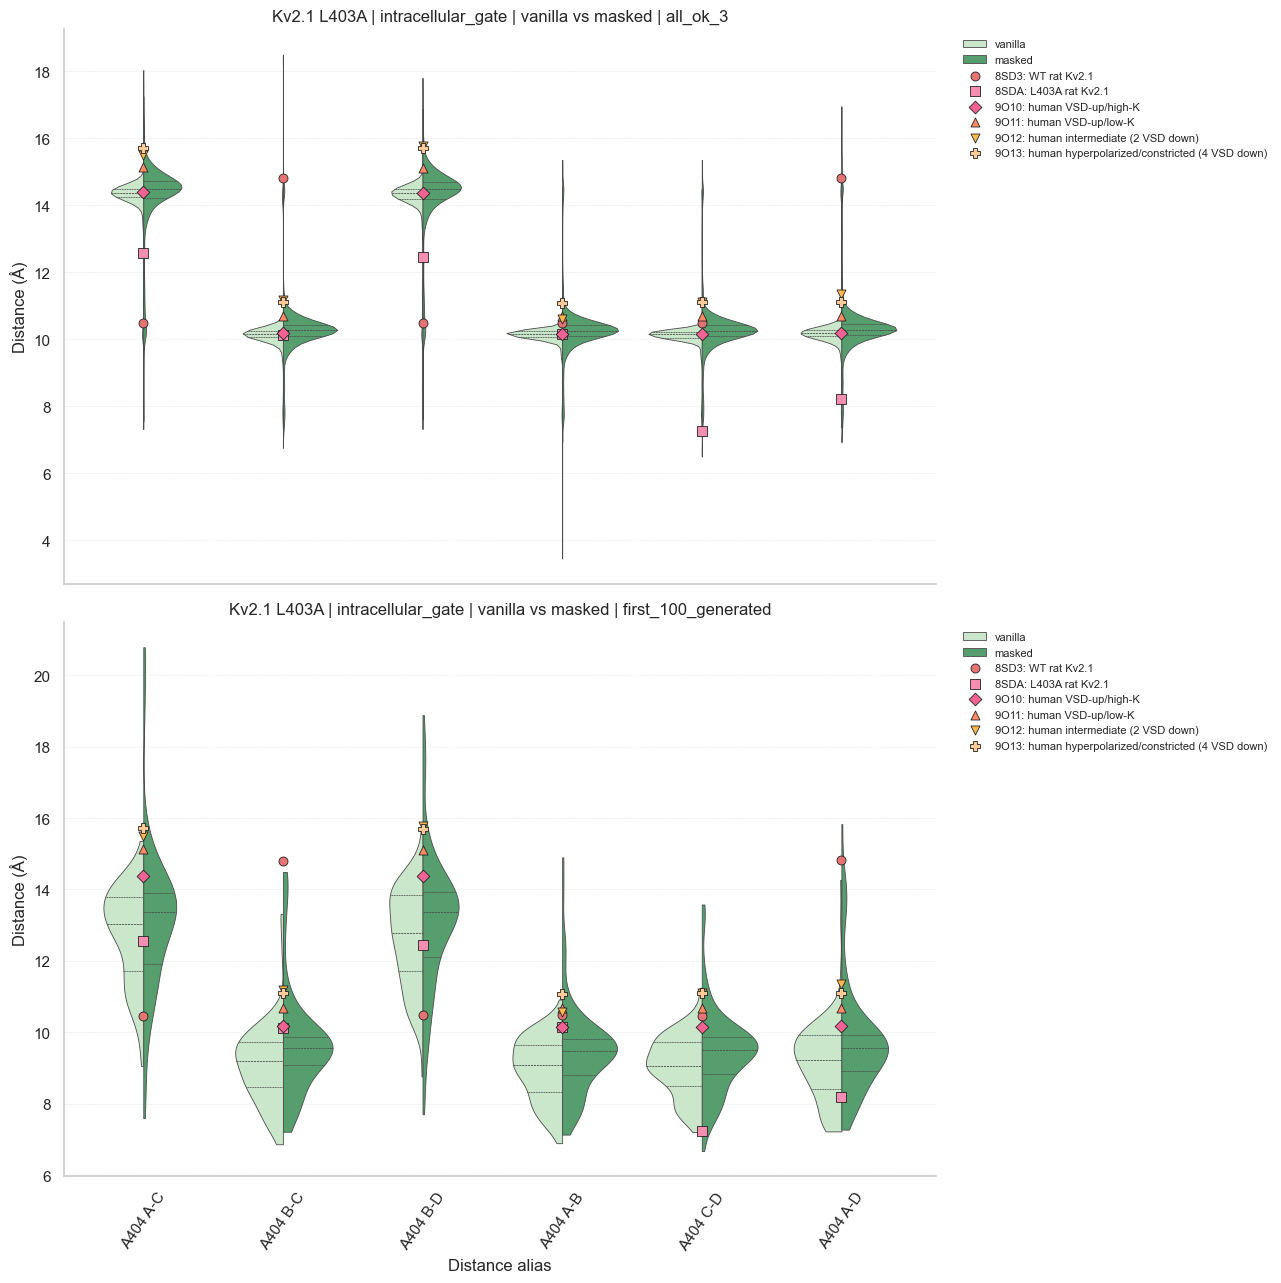

Loading Nav1.5 WT (all available models)...


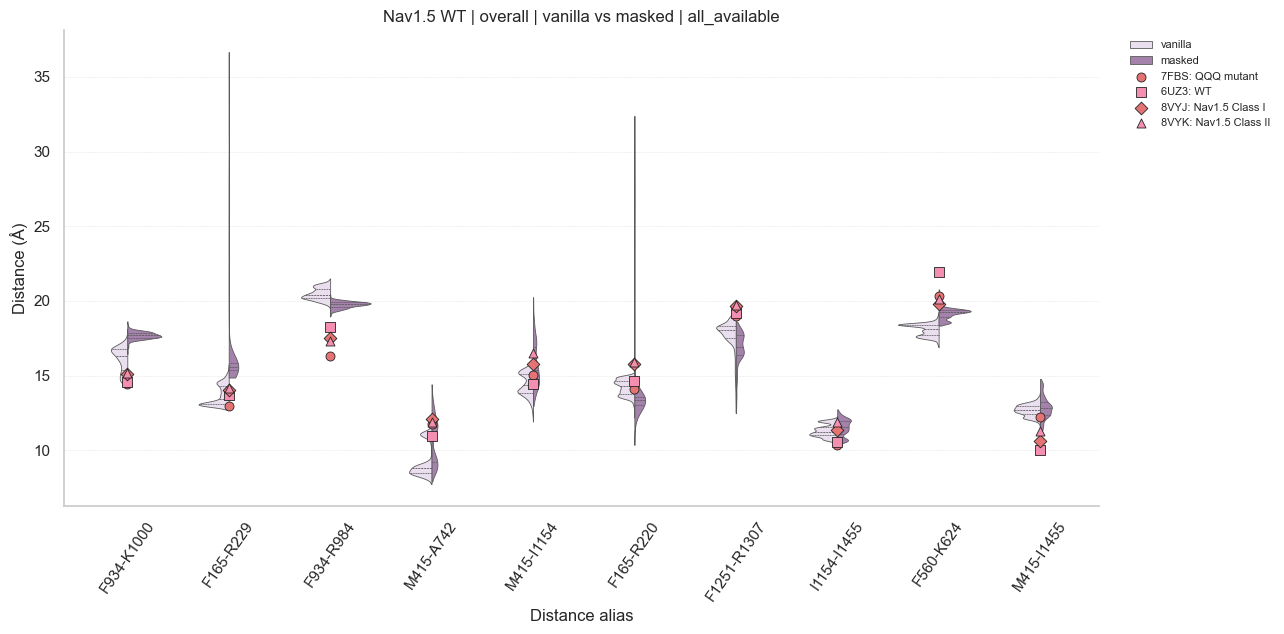

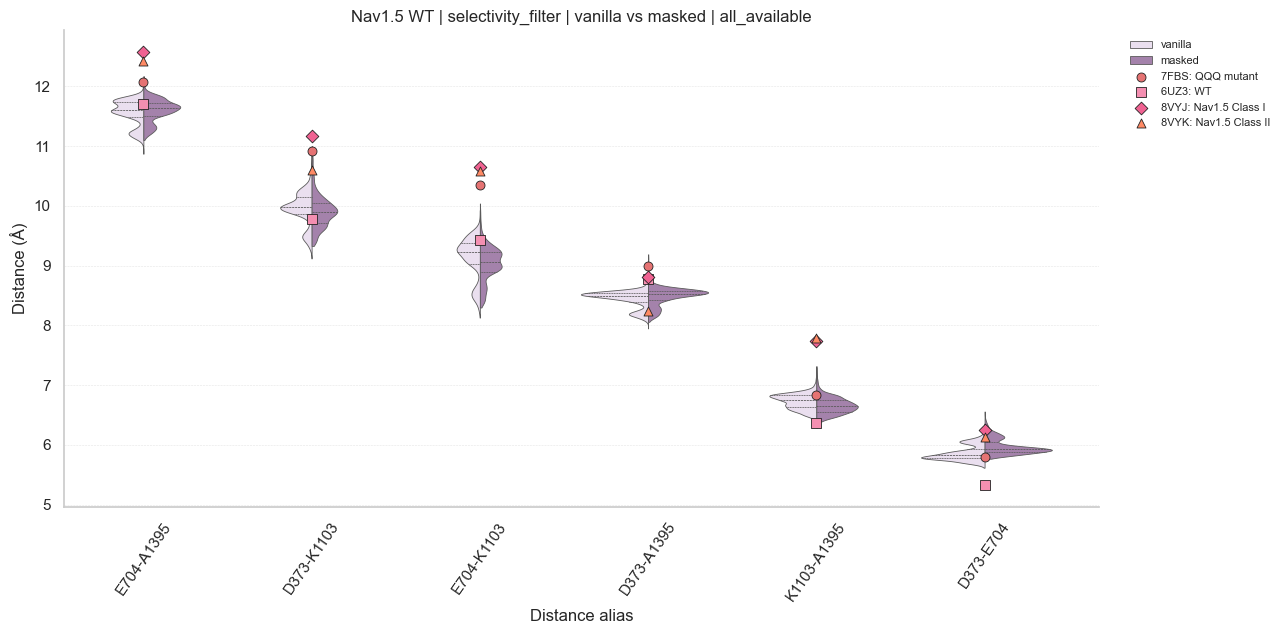

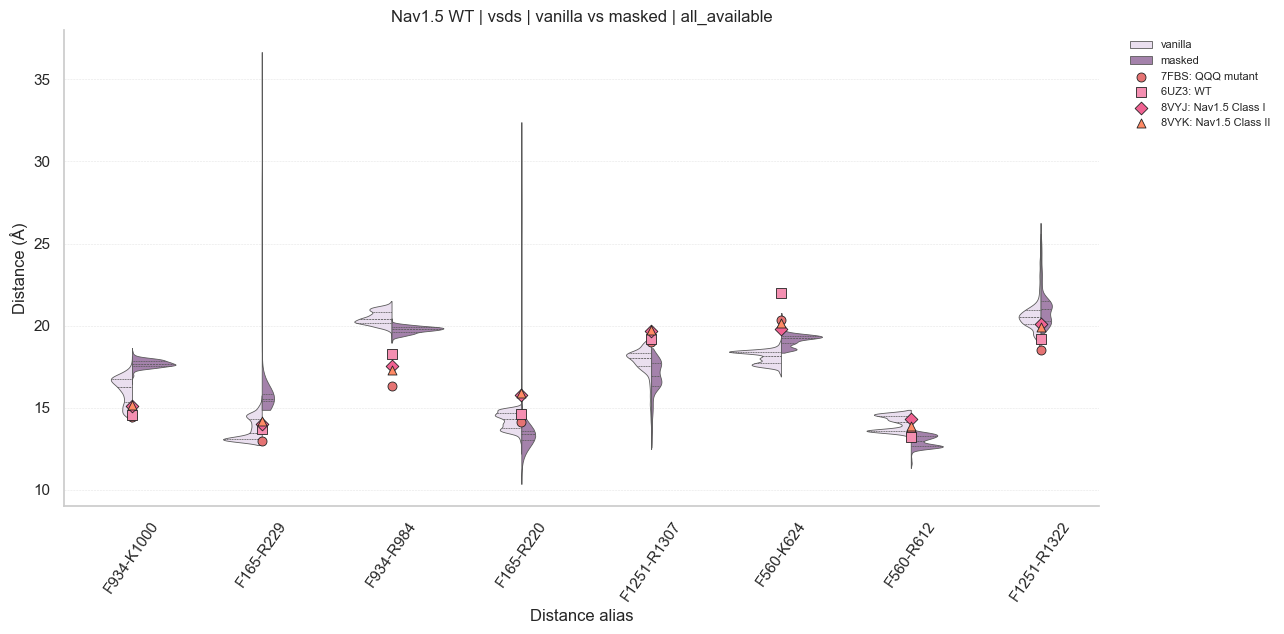

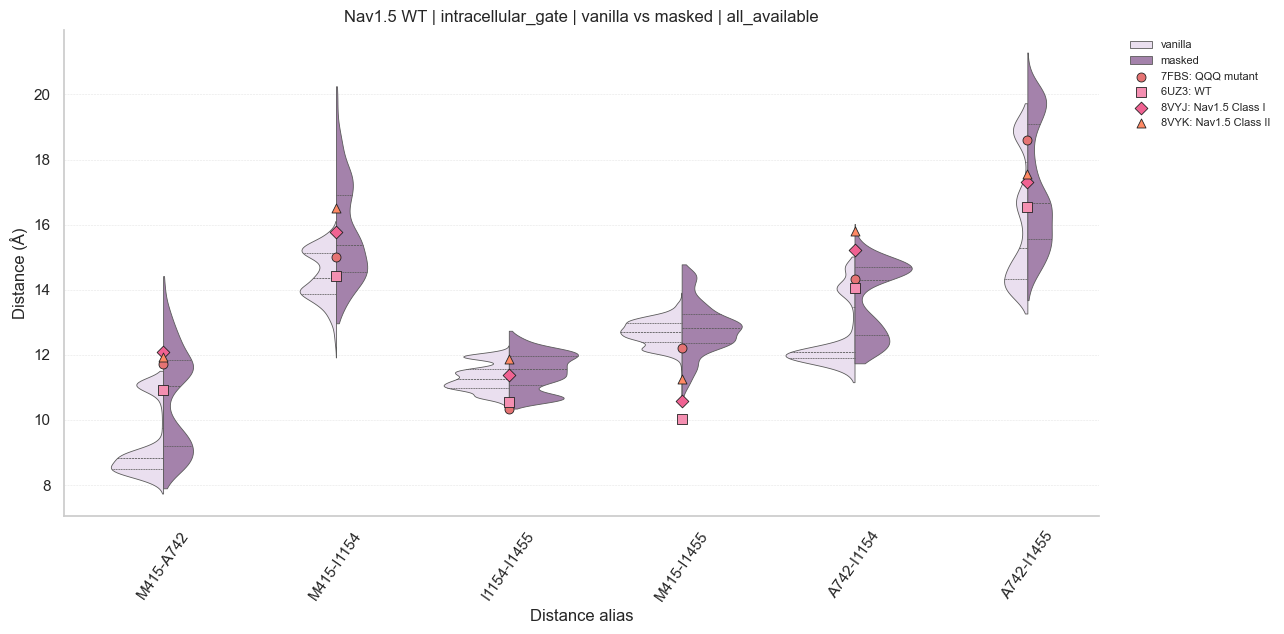

,condition,region,subset,shared_complete_distances,median_masked_to_vanilla_IQR_ratio,fraction_with_more_masked_variability,vanilla_models,masked_models
0,Cav1.2 WT,overall,all_ok_3,20,0.978472,0.500000,5000,4996
1,Cav1.2 WT,overall,first_100_generated,20,1.239983,0.750000,100,100
2,Cav1.2 WT,selectivity_filter,all_ok_3,6,0.940972,0.333333,5000,4996
3,Cav1.2 WT,selectivity_filter,first_100_generated,6,1.233894,0.833333,100,100
4,Cav1.2 WT,vsds,all_ok_3,8,1.126250,0.625000,5000,4996
5,Cav1.2 WT,vsds,first_100_generated,8,1.284803,0.750000,100,100
6,Cav1.2 WT,intracellular_gate,all_ok_3,6,1.134732,0.500000,5000,4996
7,Cav1.2 WT,intracellular_gate,first_100_generated,6,1.504435,0.666667,100,100
8,Cav1.2 G402S,overall,all_ok_3,20,1.105820,0.500000,5000,4995
9,Cav1.2 G402S,overall,first_100_generated,20,1.162083,0.800000,100,100


In [4]:
summary_rows = []
rankings = {}
selected_columns = {}

for condition, protocol_paths in DATASETS.items():
    print(f'Loading {condition}...')
    frames = load_condition(protocol_paths)
    channel = condition.split()[0]
    regions = {'overall': None, **REGION_ALIASES[channel]}
    for region, aliases in regions.items():
        alias_lookup = ({column: alias for region_aliases in REGION_ALIASES[channel].values() for alias, column in region_aliases.items()} if aliases is None else {column: alias for alias, column in aliases.items()})
        candidate_columns = ([column for region_aliases in REGION_ALIASES[channel].values() for column in region_aliases.values()] if aliases is None else aliases.values())
        ranking = rank_protocol_variability(frames, candidate_columns)
        rankings[(condition, region)] = ranking
        if ranking.empty:
            print(f'No complete shared distances: {condition} | {region}')
            continue
        selected_columns[(condition, region)] = plot_condition(condition, region, frames, ranking, alias_lookup)
        for subset in SUBSETS:
            ratios = ranking[f'{subset}_iqr_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
            summary_rows.append({
                'condition': condition, 'region': region, 'subset': subset,
                'shared_complete_distances': len(ranking),
                'median_masked_to_vanilla_IQR_ratio': ratios.median(),
                'fraction_with_more_masked_variability': (ratios > 1).mean(),
                'vanilla_models': len(frames[subset]['vanilla']),
                'masked_models': len(frames[subset]['masked']),
            })
    del frames

# NaV1.5 version of the same regional plots, using every legacy model.
for condition, protocol_paths in NAV15_DATASETS.items():
    print(f'Loading {condition} (all available models)...')
    frames = load_condition(protocol_paths, NAV15_SUBSETS)
    for region, aliases in {'overall': None, **REGION_ALIASES['Nav1.5']}.items():
        alias_lookup = ({column: alias for region_aliases in REGION_ALIASES['Nav1.5'].values() for alias, column in region_aliases.items()} if aliases is None else {column: alias for alias, column in aliases.items()})
        candidate_columns = ([column for region_aliases in REGION_ALIASES['Nav1.5'].values() for column in region_aliases.values()] if aliases is None else aliases.values())
        ranking = rank_protocol_variability(frames, candidate_columns, NAV15_SUBSETS)
        rankings[(condition, region)] = ranking
        if ranking.empty:
            print(f'No complete shared distances: {condition} | {region}')
            continue
        selected_columns[(condition, region)] = plot_condition(condition, region, frames, ranking, alias_lookup, subsets=NAV15_SUBSETS)
        ratios = ranking['all_available_iqr_ratio'].replace([np.inf, -np.inf], np.nan).dropna()
        summary_rows.append({
            'condition': condition, 'region': region, 'subset': 'all_available',
            'shared_complete_distances': len(ranking),
            'median_masked_to_vanilla_IQR_ratio': ratios.median(),
            'fraction_with_more_masked_variability': (ratios > 1).mean(),
            'vanilla_models': len(frames['all_available']['vanilla']),
            'masked_models': len(frames['all_available']['masked']),
        })
    del frames

variability_summary = pd.DataFrame(summary_rows)
display(variability_summary)


## Cross-condition summary


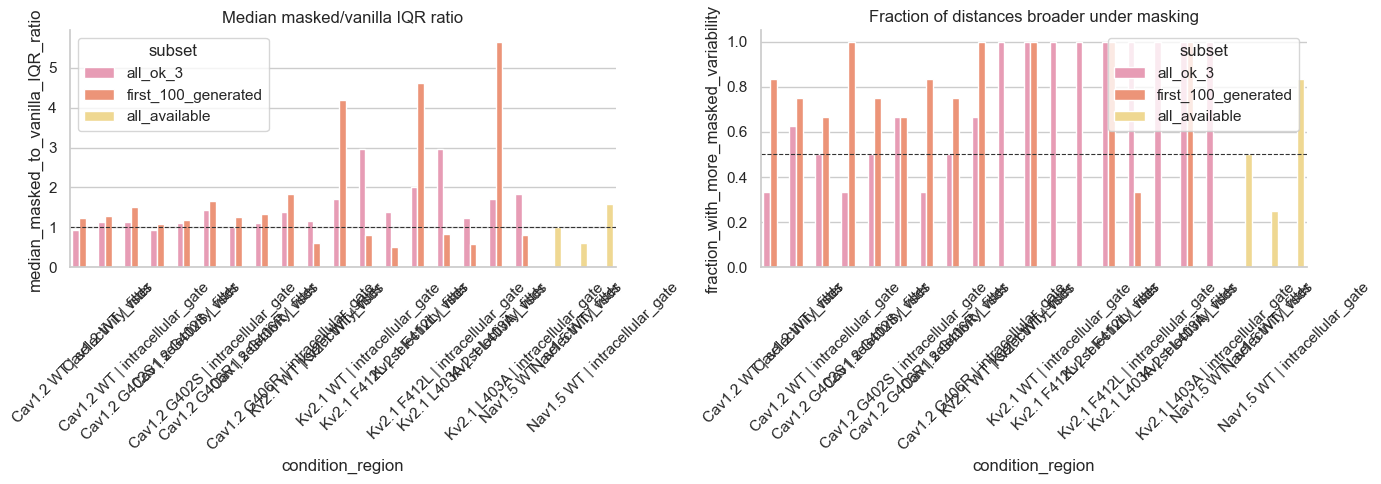

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
summary_plot = variability_summary[variability_summary['region'] != 'overall'].copy()
summary_plot['condition_region'] = summary_plot['condition'] + ' | ' + summary_plot['region']
SUMMARY_COLORS = {'all_ok_3': ACCENT_PALETTE['PINK'], 'first_100_generated': ACCENT_PALETTE['CORAL'], 'all_available': ACCENT_PALETTE['YELLOW']}
sns.barplot(data=summary_plot, x='condition_region', y='median_masked_to_vanilla_IQR_ratio', hue='subset', palette=SUMMARY_COLORS, ax=axes[0])
axes[0].axhline(1, color='#333333', linewidth=0.8, linestyle='--')
axes[0].set_title('Median masked/vanilla IQR ratio')
axes[0].tick_params(axis='x', rotation=45)
sns.barplot(data=summary_plot, x='condition_region', y='fraction_with_more_masked_variability', hue='subset', palette=SUMMARY_COLORS, ax=axes[1])
axes[1].axhline(0.5, color='#333333', linewidth=0.8, linestyle='--')
axes[1].set_title('Fraction of distances broader under masking')
axes[1].tick_params(axis='x', rotation=45)
for ax in axes:
    sns.despine(ax=ax)
fig.tight_layout()
plt.show()
